# Final Pipeline. BEA 2026 Shared Task: Vocabulary Difficulty Prediction

**Team Data Asgardians. Notebook 4 of 4 in the reproducibility pipeline.**

This is the end-to-end pipeline that produced the submitted systems, built on XLM-RoBERTa-Large and linguistic features. Training was performed on Google Colab Pro with dedicated GPUs (NVIDIA T4 and A100); stored outputs from those runs are preserved. Re-execution requires a GPU, Google Drive for model persistence, and the official task data from `https://github.com/britishcouncil/bea2026st`.

### Three models
| Model | Track | Description |
|-------|-------|-------------|
| **Closed Solo** | Closed | XLM-R Large fine-tuned per L1, without features |
| **Closed Hybrid** | Closed | XLM-R Large plus linguistic features, per L1 |
| **Open** | Open | XLM-R Large fine-tuned jointly on all L1s |

### Evaluation
- Individual, per model and per language (RMSE and Pearson)
- No ensembles or cross-model averaging

### Persistence
- Transformer models (.pt) are stored in Google Drive
- Predictions and XGBoost models are stored in the GitHub repository
- First run: trains everything (about 40 minutes)
- Subsequent runs: load and predict only (about 2 minutes)


## 1. Setup

In [ ]:
# ── Dependencias ─────────────────────────────────────────────────────────────
!pip install -q transformers datasets accelerate sentencepiece nltk seaborn xgboost shap optuna

# ── Montar Google Drive ──────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# ── Clonar / actualizar repo ────────────────────────────────────────────────
import os
from pathlib import Path

REPO_DIR = Path("/content/british_council_test")
if REPO_DIR.exists():
    !cd {REPO_DIR} && git pull --quiet
    print("✓ Repo actualizado")
else:
    !git clone https://github.com/AdrianPinedaSanchez/british_council_test.git
    print("✓ Repo clonado")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 9.2 MB/s eta 0:00:00
Mounted at /content/drive
Cloning into 'british_council_test'...
remote: Enumerating objects: 114, done.
remote: Counting objects: 100% (114/114), done.
remote: Compressing objects: 100% (79/79), done.
remote: Total 114 (delta 34), reused 106 (delta 31), pack-reused 0 (from 0)
Receiving objects: 100% (114/114), 5.01 MiB | 19.67 MiB/s, done.
Resolving deltas: 100% (34/34), done.
✓ Repo clonado


In [ ]:
import gc
import math
import os
import re
import warnings
from functools import lru_cache
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler
from transformers import (
    AutoTokenizer,
    AutoModel,
    get_linear_schedule_with_warmup,
    set_seed,
)
from scipy.stats import pearsonr
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 5)

# ═════════════════════════════════════════════════════════════════════════════
# RUTAS
# ═════════════════════════════════════════════════════════════════════════════
# Datos: repo clonado (solo lectura)
# Artefactos: Drive (persisten entre sesiones)
# ─────────────────────────────────────────────────────────────────────────────

REPO_DIR       = Path("/content/british_council_test")
DRIVE_PROJECT  = Path("/content/drive/MyDrive/bea2026")

BEA_DIR        = REPO_DIR / "bea2026st"
DATA_DIR       = BEA_DIR / "data"

FEATURES_DIR   = DRIVE_PROJECT / "features"
EMBEDDINGS_DIR = DRIVE_PROJECT / "embeddings"
MODELS_DIR     = DRIVE_PROJECT / "models"
RESULTS_DIR    = DRIVE_PROJECT / "results"
PREDICTIONS_DIR = DRIVE_PROJECT / "predictions"
SUBMISSION_DIR = DRIVE_PROJECT / "submission"

for d in [FEATURES_DIR, EMBEDDINGS_DIR, MODELS_DIR, RESULTS_DIR,
          PREDICTIONS_DIR, SUBMISSION_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ═════════════════════════════════════════════════════════════════════════════
# CONSTANTES
# ═════════════════════════════════════════════════════════════════════════════
SEED = 42
set_seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU: {gpu_name} ({gpu_mem:.1f} GB)")
else:
    gpu_mem = 0
    print("⚠️  NO HAY GPU — Runtime → Change runtime type → T4 GPU")

MODEL_NAME = "xlm-roberta-large"
MAX_LENGTH = 192
TARGET = "GLMM_score"
L1S = ["es", "de", "cn"]
L1_ORDER = L1S
L1_NAMES = {"es": "🇪🇸 Español", "de": "🇩🇪 Alemán", "cn": "🇨🇳 Mandarín"}
COMPONENT_ORDER = ["L1_source_word", "L1_context", "en_target_clue", "en_target_word"]

# ═════════════════════════════════════════════════════════════════════════════
# HIPERPARÁMETROS
# ═════════════════════════════════════════════════════════════════════════════
# ── Hiperparámetros basados en el baseline oficial ───────────────────────────
# Baseline usa: xlm-roberta-base, lr=3e-5, wd=0.1, batch=32, epochs=5
# Nosotros: xlm-roberta-large (más grande → más regularización necesaria)
# ─────────────────────────────────────────────────────────────────────────────
HPARAMS = {
    "batch_size": 16 if gpu_mem >= 30 else 8,
    "gradient_accumulation": 2 if gpu_mem >= 30 else 4,
    "learning_rate": 3e-5,        # ← igual al baseline (era 2e-5)
    "weight_decay": 0.1,          # ← igual al baseline (era 0.01 = 10x menos!)
    "warmup_ratio": 0.1,
    "epochs": 5,
    "max_grad_norm": 1.0,
}

# Per-L1 weight_decay (el baseline usa 0 para DE closed, 0.1 para el resto)
HPARAMS_PER_L1 = {
    "es": {**HPARAMS, "weight_decay": 0.1},
    "de": {**HPARAMS, "weight_decay": 0.0},   # ← baseline DE usa 0
    "cn": {**HPARAMS, "weight_decay": 0.1},
}

FAST_MODE = False  # True = 1000 filas/L1, 2 epochs
if FAST_MODE:
    HPARAMS["epochs"] = 2
    MAX_LENGTH = 128

EMB_BATCH_SIZE = 64 if torch.cuda.is_available() else 16
PCA_DIMS = 128

# ═════════════════════════════════════════════════════════════════════════════
# FUNCIONES DE EVALUACIÓN
# ═════════════════════════════════════════════════════════════════════════════
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def safe_pearson(y_pred, y_true):
    if len(y_pred) < 3 or np.std(y_pred) == 0 or np.std(y_true) == 0:
        return 0.0
    return float(pearsonr(y_true, y_pred)[0])

def evaluate_predictions(y_true, y_pred):
    return {"rmse": rmse(y_true, y_pred), "pearson": safe_pearson(y_pred, y_true)}

# ═════════════════════════════════════════════════════════════════════════════
# BASELINES OFICIALES
# ═════════════════════════════════════════════════════════════════════════════
BASELINES = {
    "closed": {
        "es": {"rmse": 1.357, "pearson": 0.748},
        "de": {"rmse": 1.328, "pearson": 0.753},
        "cn": {"rmse": 1.175, "pearson": 0.736},
    },
    "open": {
        "es": {"rmse": 1.206, "pearson": 0.787},
        "de": {"rmse": 1.149, "pearson": 0.800},
        "cn": {"rmse": 1.021, "pearson": 0.804},
    },
}

# ═════════════════════════════════════════════════════════════════════════════
# RESUMEN
# ═════════════════════════════════════════════════════════════════════════════
print(f"\n{'─' * 60}")
print(f"DATOS:      {DATA_DIR}")
print(f"DRIVE:      {DRIVE_PROJECT}")
print(f"MODELOS:    {MODELS_DIR}")
print(f"DEVICE:     {DEVICE}")
print(f"FAST_MODE:  {FAST_MODE}")
print(f"HParams:    epochs={HPARAMS['epochs']}, batch={HPARAMS['batch_size']}, "
      f"accum={HPARAMS['gradient_accumulation']}, lr={HPARAMS['learning_rate']}")
print(f"Eff. batch: {HPARAMS['batch_size'] * HPARAMS['gradient_accumulation']}")

existing = list(MODELS_DIR.glob("*.pt"))
if existing:
    print(f"\n✓ Modelos en Drive ({len(existing)}):")
    for p in sorted(existing):
        print(f"    {p.name}  ({p.stat().st_size / 1e6:.0f} MB)")
else:
    print(f"\n⚠️  Sin modelos en Drive — se entrenarán desde cero")


GPU: NVIDIA A100-SXM4-40GB (42.4 GB)

────────────────────────────────────────────────────────────
DATOS:      /content/british_council_test/bea2026st/data
DRIVE:      /content/drive/MyDrive/bea2026
MODELOS:    /content/drive/MyDrive/bea2026/models
DEVICE:     cuda
FAST_MODE:  False
HParams:    epochs=5, batch=16, accum=2, lr=3e-05
Eff. batch: 32

⚠️  Sin modelos en Drive — se entrenarán desde cero


## 2. Data loading (train, dev, and test)

In [ ]:
def load_split(split_name):
    frames = []
    for l1 in L1_ORDER:
        path = DATA_DIR / split_name / l1 / f"kvl_shared_task_{l1}_{split_name}.csv"
        if not path.exists():
            print(f"⚠️  No encontré: {path}")
            continue
        frame = pd.read_csv(path)
        frame["split"] = split_name
        frames.append(frame)
    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True)

train_df = load_split("train")
dev_df   = load_split("dev")
test_df  = load_split("test")

# Test no tiene GLMM_score — agregar dummy para compatibilidad con Dataset
if len(test_df) > 0 and TARGET not in test_df.columns:
    test_df[TARGET] = 0.0
    print("✓ Test cargado (sin labels, GLMM_score=0.0 dummy)")

# Baselines oficiales
baseline_path = BEA_DIR / "results" / "results_summary_dev.csv"
if baseline_path.exists():
    baseline_results = pd.read_csv(baseline_path)
    print(f"✓ Baselines cargados desde {baseline_path.name}")

if FAST_MODE:
    samples = []
    for l1 in L1S:
        sub = train_df[train_df["L1"] == l1]
        samples.append(sub.sample(n=min(1000, len(sub)), random_state=SEED))
    train_df = pd.concat(samples, ignore_index=True)
    print(f"⚡ FAST MODE: train reducido a {len(train_df)}")

for name, df in [("Train", train_df), ("Dev", dev_df), ("Test", test_df)]:
    if len(df) > 0:
        print(f"{name}: {df.shape} — {df['L1'].value_counts().to_dict()}")
    else:
        print(f"{name}: VACÍO")


✓ Test cargado (sin labels, GLMM_score=0.0 dummy)
✓ Baselines cargados desde results_summary_dev.csv
Train: (18273, 9) — {'es': 6091, 'de': 6091, 'cn': 6091}
Dev: (2031, 9) — {'es': 677, 'de': 677, 'cn': 677}
Test: (2244, 9) — {'es': 748, 'de': 748, 'cn': 748}


## 3. Feature Engineering

22 linguistic features covering phonology (PHOIBLE), morphology, WordNet, and the CMU Pronouncing Dictionary. Applied to train, dev, and test.


In [ ]:
import nltk
from nltk.corpus import cmudict, wordnet as wn

for pkg in ["wordnet", "omw-1.4", "cmudict"]:
    nltk.download(pkg, quiet=True)

CMU_DICT = cmudict.dict()
POS_MAP = {"noun": wn.NOUN, "verb": wn.VERB, "adjective": wn.ADJ, "adverb": wn.ADV}

L1_ABSENT_PHONEMES = {
    "es": {"TH", "DH", "SH", "ZH", "V", "Z"},
    "de": {"TH", "DH"},
    "cn": {"TH", "DH", "SH", "ZH", "R", "V", "Z", "NG"},
}
L1_UNFAMILIAR_LETTERS = {"es": set("wk"), "de": set(), "cn": set()}
PREFIXES = ["un", "re", "in", "im", "ir", "il", "dis", "en", "em",
            "non", "pre", "mis", "over", "under", "out", "sub", "super"]
SUFFIXES = ["ing", "tion", "sion", "ment", "ness", "able", "ible", "ful",
            "less", "ous", "ive", "al", "ly", "er", "est", "ed", "es", "s"]

@lru_cache(maxsize=None)
def get_synsets(word):
    return wn.synsets(str(word).lower(), lang="eng")

@lru_cache(maxsize=None)
def get_pronunciation(word):
    return CMU_DICT.get(str(word).lower(), [[]])[0]

def polysemy_pos(word, pos):
    wn_pos = POS_MAP.get(str(pos).lower())
    return len(wn.synsets(str(word).lower(), pos=wn_pos, lang="eng")) if wn_pos else len(get_synsets(word))

def is_homonym(word):
    return int(len({s.pos() for s in get_synsets(word)}) > 1)

def consonant_cluster_count(word):
    return len(re.findall(r"[bcdfghjklmnpqrstvwxyz]{2,}", str(word).lower()))

def r_count(word):
    pron = get_pronunciation(word)
    return sum(1 for p in pron if p.startswith("R")) if pron else str(word).lower().count("r")

def has_r(word):
    return int("r" in str(word).lower())

def phoneme_count(word):
    pron = get_pronunciation(word)
    if pron:
        return len(pron)
    return max(len(re.findall(r"[aeiouy]+", str(word).lower())) * 2, 1)

def silent_letter_count(word):
    return max(len(str(word)) - phoneme_count(word), 0)

def difficult_phoneme_count(word, l1):
    pron = get_pronunciation(word)
    absent = L1_ABSENT_PHONEMES.get(l1, set())
    if not pron or not absent:
        return 0
    return sum(1 for p in [re.sub(r"\d", "", ph) for ph in pron] if p in absent)

def difficult_phoneme_ratio(word, l1):
    n = phoneme_count(word)
    return difficult_phoneme_count(word, l1) / n if n > 0 else 0.0

def wordnet_frequency(word):
    total = 0
    for syn in get_synsets(word):
        for lem in syn.lemmas():
            if lem.name().lower() == str(word).lower():
                total += lem.count()
    return math.log1p(total)

def polysemy_all(word):
    return len(get_synsets(word))

def homonym_pos_count(word):
    return len({s.pos() for s in get_synsets(word)})

def max_cluster_length(word):
    clusters = re.findall(r"[bcdfghjklmnpqrstvwxyz]{2,}", str(word).lower())
    return max((len(c) for c in clusters), default=0)

def spelling_phoneme_ratio(word):
    return len(str(word)) / max(phoneme_count(word), 1)

def unfamiliar_letter_count(word, l1):
    return sum(1 for ch in str(word).lower() if ch in L1_UNFAMILIAR_LETTERS.get(l1, set()))

def has_unfamiliar(word, l1):
    return int(unfamiliar_letter_count(word, l1) > 0)

def char_ngram_distance(word1, word2, n=2):
    def ngrams(w):
        w = str(w).lower()
        return set(w[i:i+n] for i in range(len(w)-n+1)) if len(w) >= n else {w}
    s1, s2 = ngrams(word1), ngrams(word2)
    union = len(s1 | s2)
    return 1.0 - (len(s1 & s2) / union) if union > 0 else 1.0

def normalized_levenshtein(word1, word2):
    s1, s2 = str(word1).lower(), str(word2).lower()
    if len(s1) < len(s2):
        s1, s2 = s2, s1
    if len(s2) == 0:
        return float(len(s1)) / max(len(s1), 1)
    prev = list(range(len(s2) + 1))
    for i, c1 in enumerate(s1):
        curr = [i + 1]
        for j, c2 in enumerate(s2):
            curr.append(min(prev[j+1]+1, curr[j]+1, prev[j]+(c1 != c2)))
        prev = curr
    return prev[-1] / max(len(s1), len(s2))

def morphological_complexity(word):
    w = str(word).lower()
    count = 0
    for p in PREFIXES:
        if w.startswith(p) and len(w) > len(p) + 2:
            count += 1; break
    for s in sorted(SUFFIXES, key=len, reverse=True):
        if w.endswith(s) and len(w) > len(s) + 2:
            count += 1; break
    return count

def final_cluster_size(word):
    match = re.search(r"[bcdfghjklmnpqrstvwxyz]+$", str(word).lower())
    return len(match.group()) if match else 0

# ── Pipeline ─────────────────────────────────────────────────────────────────
def add_features(df):
    data = df.copy()
    w = "en_target_word"
    data["word_length"] = data[w].astype(str).str.len()
    data["clue_blanks"] = data["en_target_clue"].astype(str).str.count("_")
    data["clue_ratio"] = data["clue_blanks"] / data["word_length"].clip(lower=1)
    data["polysemy_pos"] = data.apply(lambda r: polysemy_pos(r[w], r["en_target_pos"]), axis=1)
    data["is_homonym"] = data[w].apply(is_homonym)
    data["n_consonant_clusters"] = data[w].apply(consonant_cluster_count)
    data["r_count"] = data[w].apply(r_count)
    data["has_r"] = data[w].apply(has_r)
    data["n_phonemes"] = data[w].apply(phoneme_count)
    data["silent_letters"] = data[w].apply(silent_letter_count)
    data["difficult_phonemes"] = data.apply(lambda r: difficult_phoneme_count(r[w], r["L1"]), axis=1)
    data["difficult_phoneme_ratio"] = data.apply(lambda r: difficult_phoneme_ratio(r[w], r["L1"]), axis=1)
    data["word_frequency"] = data[w].apply(wordnet_frequency)
    data["polysemy_all"] = data[w].apply(polysemy_all)
    data["homonym_pos_count"] = data[w].apply(homonym_pos_count)
    data["max_cluster_length"] = data[w].apply(max_cluster_length)
    data["spelling_phoneme_ratio"] = data[w].apply(spelling_phoneme_ratio)
    data["unfamiliar_letters"] = data.apply(lambda r: unfamiliar_letter_count(r[w], r["L1"]), axis=1)
    data["has_unfamiliar"] = data.apply(lambda r: has_unfamiliar(r[w], r["L1"]), axis=1)
    data["cosine_dist_l1_en"] = data.apply(lambda r: char_ngram_distance(r["L1_source_word"], r[w]), axis=1)
    data["levenshtein_dist"] = data.apply(lambda r: normalized_levenshtein(r["L1_source_word"], r[w]), axis=1)
    data["morphological_complexity"] = data[w].apply(morphological_complexity)
    data["final_cluster_size"] = data[w].apply(final_cluster_size)
    pos_dummies = pd.get_dummies(data["en_target_pos"].astype(str).str.lower(), prefix="pos").astype(int)
    l1_dummies = pd.get_dummies(data["L1"], prefix="l1").astype(int)
    data = pd.concat([data, pos_dummies, l1_dummies], axis=1)
    return data

FEATURE_COLS_TREE = [
    "word_length", "clue_ratio", "polysemy_pos", "is_homonym",
    "n_consonant_clusters", "r_count", "has_r", "n_phonemes", "silent_letters",
    "difficult_phonemes", "difficult_phoneme_ratio", "word_frequency",
    "polysemy_all", "homonym_pos_count", "max_cluster_length",
    "spelling_phoneme_ratio", "unfamiliar_letters", "has_unfamiliar",
    "cosine_dist_l1_en", "levenshtein_dist", "morphological_complexity",
    "final_cluster_size",
]

# ── Aplicar a train, dev, test ───────────────────────────────────────────────
print("Features para train...")
train_feat = add_features(train_df)
print("Features para dev...")
dev_feat = add_features(dev_df)
if len(test_df) > 0:
    print("Features para test...")
    test_feat = add_features(test_df)
else:
    test_feat = pd.DataFrame()

print(f"\ntrain: {train_feat.shape} | dev: {dev_feat.shape} | test: {test_feat.shape}")


Features para train...
Features para dev...
Features para test...

train: (18273, 44) | dev: (2031, 43) | test: (2244, 43)


## 4. Feature correlation and selection

In [ ]:
def correlation_table(df, features, target, groupby="L1"):
    rows = []
    groups = sorted(df[groupby].unique())
    for feat in features:
        row = {"feature": feat}
        valid = df[[feat, target]].dropna()
        row["global"] = pearsonr(valid[feat], valid[target])[0] if len(valid) > 2 and valid[feat].std() > 0 else np.nan
        for g in groups:
            sub = df[df[groupby] == g][[feat, target]].dropna()
            row[g] = pearsonr(sub[feat], sub[target])[0] if len(sub) > 2 and sub[feat].std() > 0 else np.nan
        rows.append(row)
    result = pd.DataFrame(rows).set_index("feature")
    result["abs_global"] = result["global"].abs()
    return result.sort_values("abs_global", ascending=False)

corr_table = correlation_table(train_feat, FEATURE_COLS_TREE, TARGET)

# ── Selección automática (eliminar |r| > 0.85 entre features) ───────────────
inter_corr = train_feat[FEATURE_COLS_TREE].corr(method="pearson")
THRESHOLD_INTER = 0.85

to_remove = set()
for i in range(len(FEATURE_COLS_TREE)):
    for j in range(i+1, len(FEATURE_COLS_TREE)):
        f1, f2 = FEATURE_COLS_TREE[i], FEATURE_COLS_TREE[j]
        if f1 in to_remove and f2 in to_remove:
            continue
        r = inter_corr.loc[f1, f2]
        if abs(r) > THRESHOLD_INTER:
            r1 = abs(corr_table.loc[f1, "global"]) if f1 in corr_table.index else 0
            r2 = abs(corr_table.loc[f2, "global"]) if f2 in corr_table.index else 0
            drop = f2 if r1 >= r2 else f1
            to_remove.add(drop)
            print(f"🗑  {drop:30s} — redundante (r={r:.3f})")

FEATURE_COLS_FINAL = [f for f in FEATURE_COLS_TREE if f not in to_remove]
POS_DUMMY_COLS = [c for c in train_feat.columns if c.startswith("pos_") and c in dev_feat.columns]
L1_DUMMY_COLS = [c for c in train_feat.columns if c.startswith("l1_") and c in dev_feat.columns]

print(f"\nEliminadas: {len(to_remove)} | Conservadas: {len(FEATURE_COLS_FINAL)}")
print(f"Features finales: {FEATURE_COLS_FINAL}")

# ── Guardar CSVs finales ─────────────────────────────────────────────────────
cols_to_save = ["item_id", "L1", "en_target_word", "en_target_pos", "en_target_clue",
    "L1_source_word", "L1_context", TARGET] + FEATURE_COLS_FINAL + POS_DUMMY_COLS + L1_DUMMY_COLS

train_final = train_feat[[c for c in cols_to_save if c in train_feat.columns]]
dev_final = dev_feat[[c for c in cols_to_save if c in dev_feat.columns]]
test_final = test_feat[[c for c in cols_to_save if c in test_feat.columns and c != TARGET]] if len(test_feat) > 0 else pd.DataFrame()

# Agregar TARGET dummy a test_final para compatibilidad
if len(test_final) > 0 and TARGET not in test_final.columns:
    test_final[TARGET] = 0.0

for name, df in [("train", train_final), ("dev", dev_final), ("test", test_final)]:
    if len(df) > 0:
        df.to_csv(FEATURES_DIR / f"{name}_features_final.csv", index=False)
        print(f"✓ {name}: {df.shape}")


🗑  word_length                    — redundante (r=0.909)
🗑  n_phonemes                     — redundante (r=0.933)
🗑  difficult_phoneme_ratio        — redundante (r=0.902)
🗑  unfamiliar_letters             — redundante (r=0.966)
🗑  levenshtein_dist               — redundante (r=0.892)

Eliminadas: 5 | Conservadas: 17
Features finales: ['clue_ratio', 'polysemy_pos', 'is_homonym', 'n_consonant_clusters', 'r_count', 'has_r', 'silent_letters', 'difficult_phonemes', 'word_frequency', 'polysemy_all', 'homonym_pos_count', 'max_cluster_length', 'spelling_phoneme_ratio', 'has_unfamiliar', 'cosine_dist_l1_en', 'morphological_complexity', 'final_cluster_size']
✓ train: (18273, 36)
✓ dev: (2031, 36)
✓ test: (2244, 36)


## 5. Architecture and training functions

In [ ]:
def build_input_text(row):
    return " ".join([str(row[col]) for col in COMPONENT_ORDER])

class VocabDifficultyDataset(Dataset):
    def __init__(self, df, tokenizer, feature_cols=None, max_length=256):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.feature_cols = feature_cols
        self.texts = [build_input_text(row) for _, row in self.df.iterrows()]
        self.labels = self.df[TARGET].values.astype(np.float32)
        self.item_ids = self.df["item_id"].values
        self.features = self.df[feature_cols].values.astype(np.float32) if feature_cols else None

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        enc = self.tokenizer(self.texts[idx], max_length=self.max_length,
            padding="max_length", truncation=True, return_tensors="pt")
        item = {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "label": torch.tensor(self.labels[idx], dtype=torch.float32),
            "item_id": self.item_ids[idx],
        }
        if self.features is not None:
            item["tabular_features"] = torch.tensor(self.features[idx], dtype=torch.float32)
        return item

class XLMRRegressor(nn.Module):
    def __init__(self, model_name, n_tabular_features=0, dropout=0.1):
        super().__init__()
        self.transformer = AutoModel.from_pretrained(model_name)
        hidden = self.transformer.config.hidden_size  # 1024 for Large
        self.n_tabular_features = n_tabular_features
        total = hidden + n_tabular_features
        if n_tabular_features > 0:
            self.head = nn.Sequential(
                nn.Dropout(dropout), nn.Linear(total, 256),
                nn.ReLU(), nn.Dropout(dropout), nn.Linear(256, 1))
        else:
            self.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(hidden, 1))

    def forward(self, input_ids, attention_mask, tabular_features=None):
        out = self.transformer(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0, :]
        if self.n_tabular_features > 0 and tabular_features is not None:
            cls = torch.cat([cls, tabular_features], dim=1)
        return self.head(cls).squeeze(-1)

def train_model(model, train_loader, dev_loader, hparams, device, tag=""):
    optimizer = torch.optim.AdamW(model.parameters(),
        lr=hparams["learning_rate"], weight_decay=hparams["weight_decay"])
    total_steps = (len(train_loader) * hparams["epochs"]) // hparams["gradient_accumulation"]
    warmup = int(total_steps * hparams["warmup_ratio"])
    scheduler = get_linear_schedule_with_warmup(optimizer, warmup, total_steps)
    loss_fn = nn.MSELoss()
    scaler = GradScaler()
    best_rmse, best_state = float("inf"), None
    history = []

    for epoch in range(hparams["epochs"]):
        model.train()
        losses = []
        optimizer.zero_grad()
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{hparams['epochs']} [train]")
        for step, batch in enumerate(pbar):
            ids = batch["input_ids"].to(device)
            mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)
            tab = batch.get("tabular_features")
            if tab is not None:
                tab = tab.to(device)
            with autocast("cuda"):
                preds = model(ids, mask, tab)
                loss = loss_fn(preds, labels) / hparams["gradient_accumulation"]
            scaler.scale(loss).backward()
            if (step + 1) % hparams["gradient_accumulation"] == 0:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), hparams["max_grad_norm"])
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()
                optimizer.zero_grad()
            losses.append(loss.item() * hparams["gradient_accumulation"])
            pbar.set_postfix({"loss": f"{np.mean(losses[-50:]):.4f}"})

        # ── Eval ─────────────────────────────────────────────────────────
        model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for batch in tqdm(dev_loader, desc=f"Epoch {epoch+1} [eval]"):
                ids = batch["input_ids"].to(device)
                mask = batch["attention_mask"].to(device)
                tab = batch.get("tabular_features")
                if tab is not None:
                    tab = tab.to(device)
                with autocast("cuda"):
                    preds = model(ids, mask, tab)
                all_preds.extend(preds.float().cpu().numpy())
                all_labels.extend(batch["label"].numpy())

        m = evaluate_predictions(np.array(all_labels), np.array(all_preds))
        m["epoch"] = epoch + 1
        m["train_loss"] = round(np.mean(losses), 4)
        history.append(m)
        print(f"  Epoch {epoch+1}: RMSE={m['rmse']:.4f} Pearson={m['pearson']:.4f}")
        if m["rmse"] < best_rmse:
            best_rmse = m["rmse"]
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            print(f"  ✓ Best model (RMSE={best_rmse:.4f})")

    model.load_state_dict(best_state)
    model.to(device)
    return model, history

def predict(model, loader, device):
    model.eval()
    all_preds, all_ids = [], []
    with torch.no_grad():
        for batch in tqdm(loader, desc="Predicting"):
            ids = batch["input_ids"].to(device)
            mask = batch["attention_mask"].to(device)
            tab = batch.get("tabular_features")
            if tab is not None:
                tab = tab.to(device)
            with autocast("cuda"):
                preds = model(ids, mask, tab)
            all_preds.extend(preds.float().cpu().numpy())
            all_ids.extend(batch["item_id"].numpy())
    return np.array(all_ids), np.array(all_preds)

print("✓ Arquitectura y funciones definidas")
print(f"  Solo:   [CLS](1024) → Linear(1)")
print(f"  Hybrid: [CLS](1024) + features({len(FEATURE_COLS_FINAL)}) → MLP(256) → Linear(1)")
print(f"  Open:   [CLS](1024) → Linear(1)  [todos los L1s juntos]")


✓ Arquitectura y funciones definidas
  Solo:   [CLS](1024) → Linear(1)
  Hybrid: [CLS](1024) + features(17) → MLP(256) → Linear(1)
  Open:   [CLS](1024) → Linear(1)  [todos los L1s juntos]


## 6. XGBoost with Optuna (per L1)

Linguistic features alone: do they carry signal of their own?


In [ ]:
import optuna
from xgboost import XGBRegressor
optuna.logging.set_verbosity(optuna.logging.WARNING)

FEATURES_PER_L1 = FEATURE_COLS_FINAL + POS_DUMMY_COLS

def xgb_objective(trial, l1):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1500),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "random_state": SEED, "n_jobs": -1,
    }
    tr = train_final[train_final["L1"] == l1]
    dv = dev_final[dev_final["L1"] == l1]
    feats = [f for f in FEATURES_PER_L1 if f in tr.columns and f in dv.columns]
    imp = SimpleImputer(strategy="median")
    X_tr = imp.fit_transform(tr[feats])
    X_dv = imp.transform(dv[feats])
    model = XGBRegressor(**params)
    model.fit(X_tr, tr[TARGET].values, eval_set=[(X_dv, dv[TARGET].values)], verbose=False)
    return np.sqrt(mean_squared_error(dv[TARGET].values, model.predict(X_dv)))

N_TRIALS = 100
best_xgb_models = {}
xgb_results = {}

for l1 in L1S:
    print(f"\n{'█' * 50}")
    print(f"  XGBoost Optuna — {L1_NAMES[l1]} ({N_TRIALS} trials)")
    print(f"{'█' * 50}")

    study = optuna.create_study(direction="minimize",
        sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(lambda trial, l1=l1: xgb_objective(trial, l1), n_trials=N_TRIALS)

    # Reentrenar con mejores params
    tr = train_final[train_final["L1"] == l1]
    dv = dev_final[dev_final["L1"] == l1]
    feats = [f for f in FEATURES_PER_L1 if f in tr.columns and f in dv.columns]
    imp = SimpleImputer(strategy="median")
    X_tr = imp.fit_transform(tr[feats])
    X_dv = imp.transform(dv[feats])

    best_model = XGBRegressor(**study.best_params, random_state=SEED, n_jobs=-1)
    best_model.fit(X_tr, tr[TARGET].values, eval_set=[(X_dv, dv[TARGET].values)], verbose=False)
    preds = best_model.predict(X_dv)
    best_xgb_models[l1] = (best_model, imp, feats)

    metrics = evaluate_predictions(dv[TARGET].values, preds)
    xgb_results[l1] = metrics
    print(f"  RMSE={metrics['rmse']:.4f}  Pearson={metrics['pearson']:.4f}")
    print(f"  vs closed BL ({BASELINES['closed'][l1]['rmse']}): "
          f"{'✅' if metrics['rmse'] < BASELINES['closed'][l1]['rmse'] else '❌'}")

    # Guardar predicciones
    pd.DataFrame({"item_id": dv["item_id"].values, "prediction": preds}).to_csv(
        PREDICTIONS_DIR / f"xgboost_optuna_{l1}_dev.csv", index=False)

    # Guardar modelo
    best_model.save_model(str(MODELS_DIR / f"xgboost_optuna_{l1}.json"))

print("\n✓ Todos los XGBoost guardados en Drive")



██████████████████████████████████████████████████
  XGBoost Optuna — 🇪🇸 Español (100 trials)
██████████████████████████████████████████████████
  RMSE=1.5330  Pearson=0.5999
  vs closed BL (1.357): ❌

██████████████████████████████████████████████████
  XGBoost Optuna — 🇩🇪 Alemán (100 trials)
██████████████████████████████████████████████████
  RMSE=1.4649  Pearson=0.5966
  vs closed BL (1.328): ❌

██████████████████████████████████████████████████
  XGBoost Optuna — 🇨🇳 Mandarín (100 trials)
██████████████████████████████████████████████████
  RMSE=1.3534  Pearson=0.5988
  vs closed BL (1.175): ❌

✓ Todos los XGBoost guardados en Drive


## 7. Closed Solo: XLM-R Large per L1 (no features)

Each L1 has its own fine-tuned model. If a checkpoint already exists in Drive, it is loaded and evaluated without retraining.


In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
available_features = [f for f in FEATURE_COLS_FINAL if f in train_final.columns and f in dev_final.columns]

# ═════════════════════════════════════════════════════════════════════════════
# CLOSED SOLO — per-L1
# ═════════════════════════════════════════════════════════════════════════════
solo_results = {}
solo_transformer_states = {}  # para warm-start del hybrid

for l1 in L1S:
    tr = train_df[train_df["L1"] == l1]
    dv = dev_df[dev_df["L1"] == l1]

    print(f"\n{'█' * 50}")
    print(f"  CLOSED SOLO — {L1_NAMES[l1]}  (train={len(tr)} | dev={len(dv)})")
    print(f"{'█' * 50}")

    ckpt = MODELS_DIR / f"closed_solo_{l1}.pt"
    preds_path = PREDICTIONS_DIR / f"closed_solo_{l1}_dev.csv"

    if ckpt.exists() and preds_path.exists():
        print("  ✓ Cargando checkpoint existente")
        pred_df = pd.read_csv(preds_path)
        dv_idx = dv.set_index("item_id")
        y_true = dv_idx.loc[pred_df["item_id"].values][TARGET].values
        metrics = evaluate_predictions(y_true, pred_df["prediction"].values)

        # Cargar estado del transformer para hybrid warm-start
        tmp_model = XLMRRegressor(MODEL_NAME, n_tabular_features=0)
        tmp_model.load_state_dict(torch.load(ckpt, map_location="cpu", weights_only=True))
        solo_transformer_states[l1] = {k: v.clone() for k, v in tmp_model.transformer.state_dict().items()}
        del tmp_model
    else:
        print("  Entrenando desde cero...")
        train_ds = VocabDifficultyDataset(tr, tokenizer, max_length=MAX_LENGTH)
        dev_ds = VocabDifficultyDataset(dv, tokenizer, max_length=MAX_LENGTH)
        train_loader = DataLoader(train_ds, batch_size=HPARAMS["batch_size"], shuffle=True, pin_memory=True)
        dev_loader = DataLoader(dev_ds, batch_size=HPARAMS["batch_size"]*2, shuffle=False, pin_memory=True)

        model = XLMRRegressor(MODEL_NAME, n_tabular_features=0).to(DEVICE)
        print(f"  Params: {sum(p.numel() for p in model.parameters()):,}")

        l1_hparams = HPARAMS_PER_L1.get(l1, HPARAMS)
        print(f"  HParams: lr={l1_hparams['learning_rate']}, wd={l1_hparams['weight_decay']}")
        model, history = train_model(model, train_loader, dev_loader, l1_hparams, DEVICE, tag=f"solo_{l1}")

        ids, preds = predict(model, dev_loader, DEVICE)
        dv_idx = dv.set_index("item_id")
        y_true = dv_idx.loc[ids][TARGET].values
        metrics = evaluate_predictions(y_true, preds)

        pd.DataFrame({"item_id": ids.astype(int), "prediction": preds}).to_csv(preds_path, index=False)
        torch.save(model.state_dict(), ckpt)
        solo_transformer_states[l1] = {k: v.clone() for k, v in model.transformer.state_dict().items()}

        del model, train_ds, dev_ds, train_loader, dev_loader
        gc.collect(); torch.cuda.empty_cache()

    solo_results[l1] = metrics
    bl = BASELINES["closed"][l1]["rmse"]
    print(f"  RMSE={metrics['rmse']:.4f}  Pearson={metrics['pearson']:.4f}  "
          f"vs BL({bl}): {'✅' if metrics['rmse'] < bl else '❌'}")

print("\n✓ CLOSED SOLO completado")



██████████████████████████████████████████████████
  CLOSED SOLO — 🇪🇸 Español  (train=6091 | dev=677)
██████████████████████████████████████████████████
  Entrenando desde cero...


XLMRobertaModel LOAD REPORT from: xlm-roberta-large
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Params: 559,891,457
  HParams: lr=3e-05, wd=0.1


  Epoch 1: RMSE=1.3765 Pearson=0.7065
  ✓ Best model (RMSE=1.3765)


  Epoch 2: RMSE=1.2870 Pearson=0.7721
  ✓ Best model (RMSE=1.2870)


...

  Epoch 2: RMSE=1.2291 Pearson=0.6908
  ✓ Best model (RMSE=1.2291)


  Epoch 3: RMSE=1.2774 Pearson=0.7034


  Epoch 4: RMSE=1.1892 Pearson=0.7377
  ✓ Best model (RMSE=1.1892)


  Epoch 5: RMSE=1.2373 Pearson=0.7457


  RMSE=1.1892  Pearson=0.7377  vs BL(1.175): ❌

✓ CLOSED SOLO completado


## 8. Closed Hybrid: XLM-R Large plus features, per L1

Warm start: loads the weights of the transformer already fine-tuned in the Solo configuration. Only the MLP head is trained, with a lower learning rate.


In [ ]:
hybrid_results = {}

for l1 in L1S:
    tr = train_final[train_final["L1"] == l1]
    dv = dev_final[dev_final["L1"] == l1]

    print(f"\n{'█' * 50}")
    print(f"  CLOSED HYBRID — {L1_NAMES[l1]}  (train={len(tr)} | dev={len(dv)})")
    print(f"{'█' * 50}")

    ckpt = MODELS_DIR / f"closed_hybrid_{l1}.pt"
    preds_path = PREDICTIONS_DIR / f"closed_hybrid_{l1}_dev.csv"

    if ckpt.exists() and preds_path.exists():
        print("  ✓ Cargando checkpoint existente")
        pred_df = pd.read_csv(preds_path)
        dv_idx = dv.set_index("item_id")
        y_true = dv_idx.loc[pred_df["item_id"].values][TARGET].values
        metrics = evaluate_predictions(y_true, pred_df["prediction"].values)
    else:
        print(f"  Entrenando (warm-start desde Solo, {len(available_features)} features)...")
        train_ds = VocabDifficultyDataset(tr, tokenizer, feature_cols=available_features, max_length=MAX_LENGTH)
        dev_ds = VocabDifficultyDataset(dv, tokenizer, feature_cols=available_features, max_length=MAX_LENGTH)
        train_loader = DataLoader(train_ds, batch_size=HPARAMS["batch_size"], shuffle=True, pin_memory=True)
        dev_loader = DataLoader(dev_ds, batch_size=HPARAMS["batch_size"]*2, shuffle=False, pin_memory=True)

        model = XLMRRegressor(MODEL_NAME, n_tabular_features=len(available_features)).to(DEVICE)
        if l1 in solo_transformer_states:
            model.transformer.load_state_dict(solo_transformer_states[l1])
            print("  ✓ Warm-start: pesos cargados de Solo")

        l1_hparams = HPARAMS_PER_L1.get(l1, HPARAMS)
        hybrid_hparams = l1_hparams.copy()
        hybrid_hparams["epochs"] = 3
        hybrid_hparams["learning_rate"] = 1e-5  # más bajo que solo (warm-start)
        print(f"  HParams: lr={hybrid_hparams['learning_rate']}, wd={hybrid_hparams['weight_decay']}, epochs={hybrid_hparams['epochs']}")

        model, history = train_model(model, train_loader, dev_loader, hybrid_hparams, DEVICE, tag=f"hybrid_{l1}")

        ids, preds = predict(model, dev_loader, DEVICE)
        dv_idx = dv.set_index("item_id")
        y_true = dv_idx.loc[ids][TARGET].values
        metrics = evaluate_predictions(y_true, preds)

        pd.DataFrame({"item_id": ids.astype(int), "prediction": preds}).to_csv(preds_path, index=False)
        torch.save(model.state_dict(), ckpt)

        del model, train_ds, dev_ds, train_loader, dev_loader
        gc.collect(); torch.cuda.empty_cache()

    hybrid_results[l1] = metrics
    bl = BASELINES["closed"][l1]["rmse"]
    print(f"  RMSE={metrics['rmse']:.4f}  Pearson={metrics['pearson']:.4f}  "
          f"vs BL({bl}): {'✅' if metrics['rmse'] < bl else '❌'}")

# Liberar estados de transformer
del solo_transformer_states
gc.collect()
print("\n✓ CLOSED HYBRID completado")



██████████████████████████████████████████████████
  CLOSED HYBRID — 🇪🇸 Español  (train=6091 | dev=677)
██████████████████████████████████████████████████
  Entrenando (warm-start desde Solo, 17 features)...


XLMRobertaModel LOAD REPORT from: xlm-roberta-large
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  ✓ Warm-start: pesos cargados de Solo
  HParams: lr=1e-05, wd=0.1, epochs=3


  Epoch 1: RMSE=1.2496 Pearson=0.8058
  ✓ Best model (RMSE=1.2496)


  Epoch 2: RMSE=1.2825 Pearson=0.8136


...

  ✓ Warm-start: pesos cargados de Solo
  HParams: lr=1e-05, wd=0.1, epochs=3


  Epoch 1: RMSE=1.2298 Pearson=0.7349
  ✓ Best model (RMSE=1.2298)


  Epoch 2: RMSE=1.1966 Pearson=0.7568
  ✓ Best model (RMSE=1.1966)


  Epoch 3: RMSE=1.2068 Pearson=0.7535


  RMSE=1.1966  Pearson=0.7568  vs BL(1.175): ❌

✓ CLOSED HYBRID completado


## 9. Open: XLM-R Large joint (all L1s together)

A single model trained on the three languages, equivalent to the official open baseline. It is evaluated separately for each L1.


In [ ]:
open_results = {}

print(f"\n{'█' * 50}")
print(f"  OPEN — Todos los L1s juntos")
print(f"  Train: {len(train_df)} | Dev: {len(dev_df)}")
print(f"{'█' * 50}")

ckpt = MODELS_DIR / "open_all.pt"
preds_path = PREDICTIONS_DIR / "open_all_dev.csv"

if ckpt.exists() and preds_path.exists():
    print("  ✓ Cargando checkpoint existente")
    pred_df = pd.read_csv(preds_path)
    merged = pred_df.merge(dev_df[["item_id", "L1", TARGET]], on="item_id")
    for l1 in L1S:
        sub = merged[merged["L1"] == l1]
        open_results[l1] = evaluate_predictions(sub[TARGET].values, sub["prediction"].values)
else:
    print("  Entrenando desde cero...")
    train_ds = VocabDifficultyDataset(train_df, tokenizer, max_length=MAX_LENGTH)
    dev_ds = VocabDifficultyDataset(dev_df, tokenizer, max_length=MAX_LENGTH)
    train_loader = DataLoader(train_ds, batch_size=HPARAMS["batch_size"], shuffle=True, pin_memory=True)
    dev_loader = DataLoader(dev_ds, batch_size=HPARAMS["batch_size"]*2, shuffle=False, pin_memory=True)

    model = XLMRRegressor(MODEL_NAME, n_tabular_features=0).to(DEVICE)
    print(f"  Params: {sum(p.numel() for p in model.parameters()):,}")

    model, history = train_model(model, train_loader, dev_loader, HPARAMS, DEVICE, tag="open")

    ids, preds = predict(model, dev_loader, DEVICE)
    pred_df = pd.DataFrame({"item_id": ids.astype(int), "prediction": preds})
    pred_df.to_csv(preds_path, index=False)
    torch.save(model.state_dict(), ckpt)

    merged = pred_df.merge(dev_df[["item_id", "L1", TARGET]], on="item_id")
    for l1 in L1S:
        sub = merged[merged["L1"] == l1]
        open_results[l1] = evaluate_predictions(sub[TARGET].values, sub["prediction"].values)

    del model, train_ds, dev_ds, train_loader, dev_loader
    gc.collect(); torch.cuda.empty_cache()

for l1 in L1S:
    m = open_results[l1]
    bl = BASELINES["open"][l1]["rmse"]
    print(f"  {L1_NAMES[l1]}: RMSE={m['rmse']:.4f}  Pearson={m['pearson']:.4f}  "
          f"vs BL({bl}): {'✅' if m['rmse'] < bl else '❌'}")

print("\n✓ OPEN completado")



██████████████████████████████████████████████████
  OPEN — Todos los L1s juntos
  Train: 18273 | Dev: 2031
██████████████████████████████████████████████████
  Entrenando desde cero...


XLMRobertaModel LOAD REPORT from: xlm-roberta-large
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Params: 559,891,457


  Epoch 1: RMSE=1.2213 Pearson=0.7715
  ✓ Best model (RMSE=1.2213)


  Epoch 2: RMSE=1.1547 Pearson=0.7879
  ✓ Best model (RMSE=1.1547)


  Epoch 3: RMSE=1.0462 Pearson=0.8247
  ✓ Best model (RMSE=1.0462)


  Epoch 4: RMSE=1.1127 Pearson=0.8334


  Epoch 5: RMSE=1.0593 Pearson=0.8375


  🇪🇸 Español: RMSE=1.3774  Pearson=0.7055  vs BL(1.206): ❌
  🇩🇪 Alemán: RMSE=1.3526  Pearson=0.7027  vs BL(1.149): ❌
  🇨🇳 Mandarín: RMSE=1.2711  Pearson=0.6929  vs BL(1.021): ❌

✓ OPEN completado


## 10. DEV evaluation: individual, per model and language

Each model is evaluated separately. No averaging and no ensembles.


═══════════════════════════════════════════════════════════════════════════
  EVALUACIÓN INDIVIDUAL — DEV (por modelo × idioma)
═══════════════════════════════════════════════════════════════════════════

  🇪🇸 Español


,model,rmse,pearson,vs closed,vs open
0,Closed Solo,1.191878,0.808637,✅,⭐
1,Baseline open,1.206000,0.787000,✅,
2,Closed Hybrid,1.234488,0.814080,✅,
3,Baseline closed,1.357000,0.748000,,
4,Open (joint),1.377444,0.705478,,
5,XGBoost (Optuna),1.533036,0.599914,,



  🇩🇪 Alemán


,model,rmse,pearson,vs closed,vs open
0,Closed Hybrid,1.128292,0.826052,✅,⭐
1,Closed Solo,1.146629,0.819251,✅,⭐
2,Baseline open,1.149000,0.800000,✅,
3,Baseline closed,1.328000,0.753000,,
4,Open (joint),1.352644,0.702656,,
5,XGBoost (Optuna),1.464881,0.596615,,



  🇨🇳 Mandarín


,model,rmse,pearson,vs closed,vs open
0,Baseline open,1.021000,0.804000,✅,
1,Baseline closed,1.175000,0.736000,,
2,Closed Solo,1.189222,0.737698,,
3,Closed Hybrid,1.196560,0.756759,,
4,Open (joint),1.271112,0.692917,,
5,XGBoost (Optuna),1.353401,0.598777,,


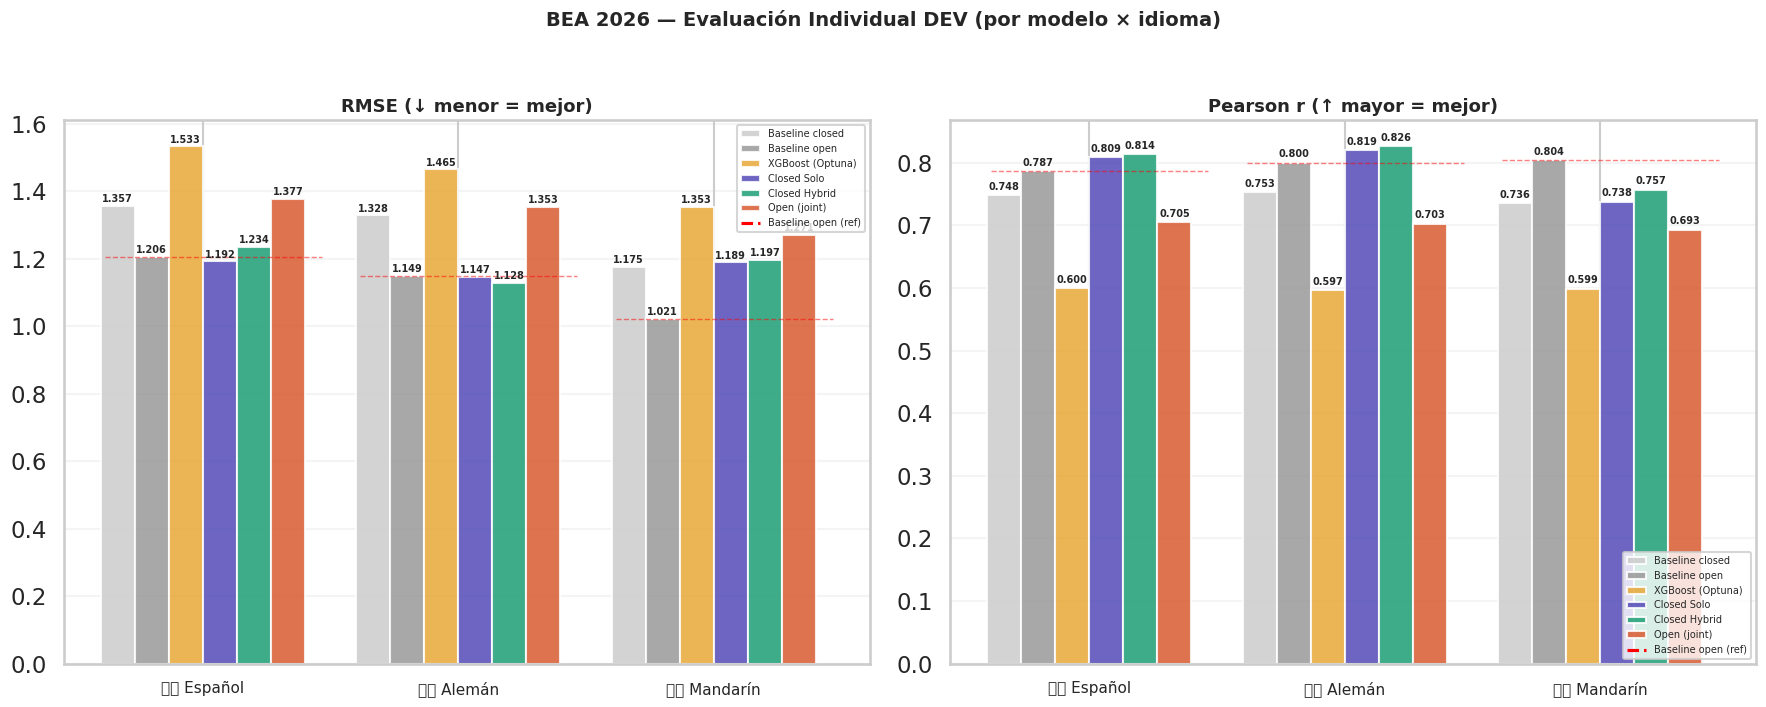

✓ /content/drive/MyDrive/bea2026/results/dev_individual_comparison.png


In [ ]:
from matplotlib.lines import Line2D

# ═════════════════════════════════════════════════════════════════════════════
# Tabla comparativa
# ═════════════════════════════════════════════════════════════════════════════
all_dev_results = []

for l1 in L1S:
    all_dev_results.append({"L1": l1, "model": "Baseline closed", **BASELINES["closed"][l1]})
    all_dev_results.append({"L1": l1, "model": "Baseline open", **BASELINES["open"][l1]})
    if l1 in xgb_results:
        all_dev_results.append({"L1": l1, "model": "XGBoost (Optuna)", **xgb_results[l1]})
    if l1 in solo_results:
        all_dev_results.append({"L1": l1, "model": "Closed Solo", **solo_results[l1]})
    if l1 in hybrid_results:
        all_dev_results.append({"L1": l1, "model": "Closed Hybrid", **hybrid_results[l1]})
    if l1 in open_results:
        all_dev_results.append({"L1": l1, "model": "Open (joint)", **open_results[l1]})

dev_df_results = pd.DataFrame(all_dev_results)

print("═" * 75)
print("  EVALUACIÓN INDIVIDUAL — DEV (por modelo × idioma)")
print("═" * 75)

for l1 in L1S:
    sub = dev_df_results[dev_df_results["L1"] == l1].sort_values("rmse").reset_index(drop=True)
    bl_c = BASELINES["closed"][l1]["rmse"]
    bl_o = BASELINES["open"][l1]["rmse"]
    sub["vs closed"] = sub["rmse"].apply(lambda x: "✅" if x < bl_c else "")
    sub["vs open"] = sub["rmse"].apply(lambda x: "⭐" if x < bl_o else "")
    print(f"\n  {L1_NAMES[l1]}")
    display(sub[["model", "rmse", "pearson", "vs closed", "vs open"]])

dev_df_results.to_csv(RESULTS_DIR / "dev_results_individual.csv", index=False)

# ═════════════════════════════════════════════════════════════════════════════
# Gráfica
# ═════════════════════════════════════════════════════════════════════════════
COLORS = {
    "Baseline closed": "#CCCCCC",
    "Baseline open": "#999999",
    "XGBoost (Optuna)": "#E8A838",
    "Closed Solo": "#534AB7",
    "Closed Hybrid": "#1D9E75",
    "Open (joint)": "#D85A30",
}
models_plot = [m for m in COLORS if m in dev_df_results["model"].values]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, metric, title in zip(axes, ["rmse", "pearson"],
    ["RMSE (↓ menor = mejor)", "Pearson r (↑ mayor = mejor)"]):

    x = np.arange(len(L1S))
    w = 0.8 / max(len(models_plot), 1)

    for i, mn in enumerate(models_plot):
        vals = []
        for l1 in L1S:
            row = dev_df_results[(dev_df_results["L1"] == l1) & (dev_df_results["model"] == mn)]
            vals.append(row[metric].values[0] if len(row) > 0 else 0)
        bars = ax.bar(x + i*w, vals, w, label=mn, color=COLORS[mn], alpha=0.85, edgecolor="white")
        for bar, val in zip(bars, vals):
            if val > 0:
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                        f"{val:.3f}", ha="center", va="bottom", fontsize=7, fontweight="bold")

    for l1_idx, l1 in enumerate(L1S):
        bl = BASELINES["open"][l1][metric]
        ax.hlines(bl, l1_idx - 0.05, l1_idx + w*len(models_plot),
                  colors="red", linestyles="--", linewidth=1, alpha=0.5)

    ax.set_xticks(x + w*(len(models_plot)-1)/2)
    ax.set_xticklabels([L1_NAMES[l1] for l1 in L1S], fontsize=11)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.grid(axis="y", alpha=0.2)

    h, lb = ax.get_legend_handles_labels()
    h.append(Line2D([0], [0], color="red", linestyle="--"))
    lb.append("Baseline open (ref)")
    ax.legend(h, lb, fontsize=7, loc="upper right" if metric == "rmse" else "lower right")

plt.suptitle("BEA 2026 — Evaluación Individual DEV (por modelo × idioma)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "dev_individual_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ {RESULTS_DIR / 'dev_individual_comparison.png'}")


## 10b. Final retraining on train plus dev (for submission)

Rationale: the metrics in Sections 7 to 9 use dev for validation. For the final test predictions we want to exploit all labeled data (train plus dev, 100 percent of the annotations).

Each model is retrained from scratch on the combined train and dev sets. If a `_final.pt` checkpoint already exists in Drive, it is loaded instead of retraining.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Reentrenamiento FINAL — train+dev combinados
# ══════════════════════════════════════════════════════════════════════════════

full_df = pd.concat([train_df, dev_df], ignore_index=True)
full_final = pd.concat([train_final, dev_final], ignore_index=True)
print(f"Datos combinados: {len(full_df)} filas (train={len(train_df)} + dev={len(dev_df)})")

FINAL_EPOCHS = HPARAMS["epochs"]  # mismas épocas que en la fase de evaluación

# ═════════════════════════════════════════════════════════════════════════════
# CLOSED SOLO FINAL (per-L1)
# ═════════════════════════════════════════════════════════════════════════════
print(f"\n{'█' * 60}")
print(f"  CLOSED SOLO — Reentrenamiento FINAL (train+dev)")
print(f"{'█' * 60}")

for l1 in L1S:
    ckpt_final = MODELS_DIR / f"closed_solo_{l1}_final.pt"

    if ckpt_final.exists():
        print(f"\n  {L1_NAMES[l1]}: ✓ _final.pt ya existe en Drive — saltando")
        continue

    data = full_df[full_df["L1"] == l1]
    print(f"\n  {L1_NAMES[l1]}: entrenando con {len(data)} filas...")

    ds = VocabDifficultyDataset(data, tokenizer, max_length=MAX_LENGTH)
    loader = DataLoader(ds, batch_size=HPARAMS["batch_size"], shuffle=True, pin_memory=True)

    l1_hparams = HPARAMS_PER_L1.get(l1, HPARAMS)
    # Sin dev_loader — entrenamos todas las épocas (no hay early stopping)
    final_hparams = l1_hparams.copy()
    final_hparams["epochs"] = FINAL_EPOCHS

    model = XLMRRegressor(MODEL_NAME, n_tabular_features=0).to(DEVICE)

    # Entrenar sin eval (usamos todas las épocas)
    optimizer = torch.optim.AdamW(model.parameters(),
        lr=final_hparams["learning_rate"], weight_decay=final_hparams["weight_decay"])
    total_steps = (len(loader) * final_hparams["epochs"]) // final_hparams["gradient_accumulation"]
    warmup = int(total_steps * final_hparams["warmup_ratio"])
    scheduler = get_linear_schedule_with_warmup(optimizer, warmup, total_steps)
    loss_fn = nn.MSELoss()
    scaler = GradScaler()

    model.train()
    for epoch in range(final_hparams["epochs"]):
        losses = []
        optimizer.zero_grad()
        pbar = tqdm(loader, desc=f"  {l1} Epoch {epoch+1}/{final_hparams['epochs']}")
        for step, batch in enumerate(pbar):
            ids = batch["input_ids"].to(DEVICE)
            mask = batch["attention_mask"].to(DEVICE)
            labels = batch["label"].to(DEVICE)
            with autocast("cuda"):
                preds = model(ids, mask)
                loss = loss_fn(preds, labels) / final_hparams["gradient_accumulation"]
            scaler.scale(loss).backward()
            if (step + 1) % final_hparams["gradient_accumulation"] == 0:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), final_hparams["max_grad_norm"])
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()
                optimizer.zero_grad()
            losses.append(loss.item() * final_hparams["gradient_accumulation"])
            pbar.set_postfix({"loss": f"{np.mean(losses[-50:]):.4f}"})
        print(f"    Epoch {epoch+1}: loss={np.mean(losses):.4f}")

    torch.save(model.state_dict(), ckpt_final)
    print(f"  ✓ Guardado: {ckpt_final.name}")
    del model; gc.collect(); torch.cuda.empty_cache()

# ═════════════════════════════════════════════════════════════════════════════
# CLOSED HYBRID FINAL (per-L1, warm-start desde solo_final)
# ═════════════════════════════════════════════════════════════════════════════
print(f"\n{'█' * 60}")
print(f"  CLOSED HYBRID — Reentrenamiento FINAL (train+dev)")
print(f"{'█' * 60}")

for l1 in L1S:
    ckpt_final = MODELS_DIR / f"closed_hybrid_{l1}_final.pt"
    solo_final = MODELS_DIR / f"closed_solo_{l1}_final.pt"

    if ckpt_final.exists():
        print(f"\n  {L1_NAMES[l1]}: ✓ _final.pt ya existe en Drive — saltando")
        continue

    if not solo_final.exists():
        print(f"\n  {L1_NAMES[l1]}: ⚠️ Necesita closed_solo_{l1}_final.pt primero")
        continue

    data = full_final[full_final["L1"] == l1]
    print(f"\n  {L1_NAMES[l1]}: entrenando con {len(data)} filas + {len(available_features)} features...")

    ds = VocabDifficultyDataset(data, tokenizer, feature_cols=available_features, max_length=MAX_LENGTH)
    loader = DataLoader(ds, batch_size=HPARAMS["batch_size"], shuffle=True, pin_memory=True)

    model = XLMRRegressor(MODEL_NAME, n_tabular_features=len(available_features)).to(DEVICE)

    # Warm-start desde solo_final
    solo_state = torch.load(solo_final, map_location=DEVICE, weights_only=True)
    transformer_state = {k: v for k, v in solo_state.items() if k.startswith("transformer.")}
    model.load_state_dict(transformer_state, strict=False)
    print(f"  ✓ Warm-start desde {solo_final.name}")
    del solo_state, transformer_state

    l1_hparams = HPARAMS_PER_L1.get(l1, HPARAMS)
    hybrid_hparams = l1_hparams.copy()
    hybrid_hparams["epochs"] = 3
    hybrid_hparams["learning_rate"] = 1e-5

    optimizer = torch.optim.AdamW(model.parameters(),
        lr=hybrid_hparams["learning_rate"], weight_decay=hybrid_hparams["weight_decay"])
    total_steps = (len(loader) * hybrid_hparams["epochs"]) // hybrid_hparams["gradient_accumulation"]
    warmup = int(total_steps * hybrid_hparams["warmup_ratio"])
    scheduler = get_linear_schedule_with_warmup(optimizer, warmup, total_steps)
    loss_fn = nn.MSELoss()
    scaler = GradScaler()

    model.train()
    for epoch in range(hybrid_hparams["epochs"]):
        losses = []
        optimizer.zero_grad()
        pbar = tqdm(loader, desc=f"  {l1} Epoch {epoch+1}/{hybrid_hparams['epochs']}")
        for step, batch in enumerate(pbar):
            ids = batch["input_ids"].to(DEVICE)
            mask = batch["attention_mask"].to(DEVICE)
            labels = batch["label"].to(DEVICE)
            tab = batch["tabular_features"].to(DEVICE)
            with autocast("cuda"):
                preds = model(ids, mask, tab)
                loss = loss_fn(preds, labels) / hybrid_hparams["gradient_accumulation"]
            scaler.scale(loss).backward()
            if (step + 1) % hybrid_hparams["gradient_accumulation"] == 0:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), hybrid_hparams["max_grad_norm"])
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()
                optimizer.zero_grad()
            losses.append(loss.item() * hybrid_hparams["gradient_accumulation"])
            pbar.set_postfix({"loss": f"{np.mean(losses[-50:]):.4f}"})
        print(f"    Epoch {epoch+1}: loss={np.mean(losses):.4f}")

    torch.save(model.state_dict(), ckpt_final)
    print(f"  ✓ Guardado: {ckpt_final.name}")
    del model; gc.collect(); torch.cuda.empty_cache()

# ═════════════════════════════════════════════════════════════════════════════
# OPEN FINAL (joint, todos los L1s)
# ═════════════════════════════════════════════════════════════════════════════
print(f"\n{'█' * 60}")
print(f"  OPEN — Reentrenamiento FINAL (train+dev)")
print(f"{'█' * 60}")

ckpt_final = MODELS_DIR / "open_all_final.pt"

if ckpt_final.exists():
    print("  ✓ _final.pt ya existe en Drive — saltando")
else:
    print(f"  Entrenando con {len(full_df)} filas (todos los L1s)...")

    ds = VocabDifficultyDataset(full_df, tokenizer, max_length=MAX_LENGTH)
    loader = DataLoader(ds, batch_size=HPARAMS["batch_size"], shuffle=True, pin_memory=True)

    model = XLMRRegressor(MODEL_NAME, n_tabular_features=0).to(DEVICE)

    optimizer = torch.optim.AdamW(model.parameters(),
        lr=HPARAMS["learning_rate"], weight_decay=HPARAMS["weight_decay"])
    total_steps = (len(loader) * FINAL_EPOCHS) // HPARAMS["gradient_accumulation"]
    warmup = int(total_steps * HPARAMS["warmup_ratio"])
    scheduler = get_linear_schedule_with_warmup(optimizer, warmup, total_steps)
    loss_fn = nn.MSELoss()
    scaler = GradScaler()

    model.train()
    for epoch in range(FINAL_EPOCHS):
        losses = []
        optimizer.zero_grad()
        pbar = tqdm(loader, desc=f"  Open Epoch {epoch+1}/{FINAL_EPOCHS}")
        for step, batch in enumerate(pbar):
            ids = batch["input_ids"].to(DEVICE)
            mask = batch["attention_mask"].to(DEVICE)
            labels = batch["label"].to(DEVICE)
            with autocast("cuda"):
                preds = model(ids, mask)
                loss = loss_fn(preds, labels) / HPARAMS["gradient_accumulation"]
            scaler.scale(loss).backward()
            if (step + 1) % HPARAMS["gradient_accumulation"] == 0:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), HPARAMS["max_grad_norm"])
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()
                optimizer.zero_grad()
            losses.append(loss.item() * HPARAMS["gradient_accumulation"])
            pbar.set_postfix({"loss": f"{np.mean(losses[-50:]):.4f}"})
        print(f"    Epoch {epoch+1}: loss={np.mean(losses):.4f}")

    torch.save(model.state_dict(), ckpt_final)
    print(f"  ✓ Guardado: {ckpt_final.name}")
    del model; gc.collect(); torch.cuda.empty_cache()

# ── XGBoost FINAL (retrain con train+dev) ────────────────────────────────────
print(f"\n{'█' * 60}")
print(f"  XGBoost Optuna — Reentrenamiento FINAL (train+dev)")
print(f"{'█' * 60}")

best_xgb_models_final = {}
for l1 in L1S:
    xgb_final_path = MODELS_DIR / f"xgboost_optuna_{l1}_final.json"

    if xgb_final_path.exists():
        print(f"  {L1_NAMES[l1]}: ✓ ya existe — cargando")
        from xgboost import XGBRegressor as XGB
        m = XGB()
        m.load_model(str(xgb_final_path))
        # Reconstruir imputer con full data
        feats = [f for f in FEATURES_PER_L1 if f in full_final.columns]
        imp = SimpleImputer(strategy="median")
        imp.fit(full_final[full_final["L1"] == l1][feats])
        best_xgb_models_final[l1] = (m, imp, feats)
        continue

    if l1 not in best_xgb_models:
        print(f"  {L1_NAMES[l1]}: ⚠️ sin modelo Optuna base — saltando")
        continue

    base_model, _, feats = best_xgb_models[l1]
    data = full_final[full_final["L1"] == l1]
    feats_avail = [f for f in feats if f in data.columns]

    imp = SimpleImputer(strategy="median")
    X = imp.fit_transform(data[feats_avail])
    y = data[TARGET].values

    # Reentrenar con mismos params pero toda la data
    final_model = XGBRegressor(**base_model.get_params())
    final_model.fit(X, y, verbose=False)
    final_model.save_model(str(xgb_final_path))
    best_xgb_models_final[l1] = (final_model, imp, feats_avail)
    print(f"  {L1_NAMES[l1]}: ✓ reentrenado con {len(data)} filas → {xgb_final_path.name}")

print(f"\n✓ Todos los modelos FINALES guardados en Drive")
existing_final = list(MODELS_DIR.glob("*_final.*"))
for p in sorted(existing_final):
    print(f"    {p.name}  ({p.stat().st_size / 1e6:.1f} MB)")


Datos combinados: 20304 filas (train=18273 + dev=2031)

████████████████████████████████████████████████████████████
  CLOSED SOLO — Reentrenamiento FINAL (train+dev)
████████████████████████████████████████████████████████████

  🇪🇸 Español: entrenando con 6768 filas...


XLMRobertaModel LOAD REPORT from: xlm-roberta-large
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


    Epoch 1: loss=3.1767


    Epoch 2: loss=1.8578


    Epoch 3: loss=1.1387


...

    Epoch 1: loss=2.0480


    Epoch 2: loss=1.0363


    Epoch 3: loss=0.6136


    Epoch 4: loss=0.3991


    Epoch 5: loss=0.2535
  ✓ Guardado: open_all_final.pt

████████████████████████████████████████████████████████████
  XGBoost Optuna — Reentrenamiento FINAL (train+dev)
████████████████████████████████████████████████████████████
  🇪🇸 Español: ✓ reentrenado con 6768 filas → xgboost_optuna_es_final.json
  🇩🇪 Alemán: ✓ reentrenado con 6768 filas → xgboost_optuna_de_final.json
  🇨🇳 Mandarín: ✓ reentrenado con 6768 filas → xgboost_optuna_cn_final.json

✓ Todos los modelos FINALES guardados en Drive
    closed_hybrid_cn_final.pt  (2240.8 MB)
    closed_hybrid_de_final.pt  (2240.8 MB)
    closed_hybrid_es_final.pt  (2240.8 MB)
    closed_solo_cn_final.pt  (2239.7 MB)
    closed_solo_de_final.pt  (2239.7 MB)
    closed_solo_es_final.pt  (2239.7 MB)
    open_all_final.pt  (2239.7 MB)
    xgboost_optuna_cn_final.json  (1.6 MB)
    xgboost_optuna_de_final.json  (1.0 MB)
    xgboost_optuna_es_final.json  (0.6 MB)


## 11. TEST predictions

Uses the FINAL models trained on train plus dev. Each output CSV contains only `item_id` and `GLMM_score`.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Predicciones TEST — usando modelos FINALES (train+dev)
# ══════════════════════════════════════════════════════════════════════════════

for track in ["closed", "open"]:
    for l1 in L1S:
        (SUBMISSION_DIR / track / l1).mkdir(parents=True, exist_ok=True)

if len(test_df) == 0:
    print("⚠️ No hay datos de test")
else:
    # ── XGBoost Optuna FINAL → TEST (closed) ─────────────────────────────
    print("═" * 50)
    print("  XGBoost Optuna (FINAL) → TEST")
    for l1 in L1S:
        if l1 not in best_xgb_models_final:
            print(f"  ⚠️ {l1}: sin modelo final"); continue
        model, imp, feats = best_xgb_models_final[l1]
        ts = test_final[test_final["L1"] == l1]
        X = imp.transform(ts[[f for f in feats if f in ts.columns]].values)
        preds = model.predict(X)
        pd.DataFrame({"item_id": ts["item_id"].values, "GLMM_score": preds}).to_csv(
            SUBMISSION_DIR / "closed" / l1 / "predictions_xgboost.csv", index=False)
        print(f"  {L1_NAMES[l1]}: {len(preds)} predicciones")

    # ── Closed Solo FINAL → TEST ─────────────────────────────────────────
    print("\n" + "═" * 50)
    print("  Closed Solo (FINAL) → TEST")
    for l1 in L1S:
        ckpt = MODELS_DIR / f"closed_solo_{l1}_final.pt"
        if not ckpt.exists():
            print(f"  ⚠️ {l1}: sin checkpoint final"); continue
        model = XLMRRegressor(MODEL_NAME, 0).to(DEVICE)
        model.load_state_dict(torch.load(ckpt, map_location=DEVICE, weights_only=True))
        ts = test_df[test_df["L1"] == l1]
        ds = VocabDifficultyDataset(ts, tokenizer, max_length=MAX_LENGTH)
        loader = DataLoader(ds, batch_size=HPARAMS["batch_size"]*2, shuffle=False, pin_memory=True)
        ids, preds = predict(model, loader, DEVICE)
        pd.DataFrame({"item_id": ids.astype(int), "GLMM_score": preds}).to_csv(
            SUBMISSION_DIR / "closed" / l1 / "predictions_closed_solo.csv", index=False)
        print(f"  {L1_NAMES[l1]}: {len(preds)} predicciones")
        del model; gc.collect(); torch.cuda.empty_cache()

    # ── Closed Hybrid FINAL → TEST ───────────────────────────────────────
    print("\n" + "═" * 50)
    print("  Closed Hybrid (FINAL) → TEST")
    for l1 in L1S:
        ckpt = MODELS_DIR / f"closed_hybrid_{l1}_final.pt"
        if not ckpt.exists():
            print(f"  ⚠️ {l1}: sin checkpoint final"); continue
        model = XLMRRegressor(MODEL_NAME, len(available_features)).to(DEVICE)
        model.load_state_dict(torch.load(ckpt, map_location=DEVICE, weights_only=True))
        ts = test_final[test_final["L1"] == l1]
        ds = VocabDifficultyDataset(ts, tokenizer, feature_cols=available_features, max_length=MAX_LENGTH)
        loader = DataLoader(ds, batch_size=HPARAMS["batch_size"]*2, shuffle=False, pin_memory=True)
        ids, preds = predict(model, loader, DEVICE)
        pd.DataFrame({"item_id": ids.astype(int), "GLMM_score": preds}).to_csv(
            SUBMISSION_DIR / "closed" / l1 / "predictions_closed_hybrid.csv", index=False)
        print(f"  {L1_NAMES[l1]}: {len(preds)} predicciones")
        del model; gc.collect(); torch.cuda.empty_cache()

    # ── Open FINAL → TEST ────────────────────────────────────────────────
    print("\n" + "═" * 50)
    print("  Open (FINAL) → TEST")
    ckpt = MODELS_DIR / "open_all_final.pt"
    if ckpt.exists():
        model = XLMRRegressor(MODEL_NAME, 0).to(DEVICE)
        model.load_state_dict(torch.load(ckpt, map_location=DEVICE, weights_only=True))
        ds = VocabDifficultyDataset(test_df, tokenizer, max_length=MAX_LENGTH)
        loader = DataLoader(ds, batch_size=HPARAMS["batch_size"]*2, shuffle=False, pin_memory=True)
        ids, preds = predict(model, loader, DEVICE)
        pred_df = pd.DataFrame({"item_id": ids.astype(int), "GLMM_score": preds})
        pred_merged = pred_df.merge(test_df[["item_id", "L1"]], on="item_id")
        for l1 in L1S:
            sub = pred_merged[pred_merged["L1"] == l1][["item_id", "GLMM_score"]]
            sub.to_csv(SUBMISSION_DIR / "open" / l1 / "predictions_open.csv", index=False)
            print(f"  {L1_NAMES[l1]}: {len(sub)} predicciones")
        del model; gc.collect(); torch.cuda.empty_cache()
    else:
        print("  ⚠️ Sin checkpoint open_all_final.pt")

    print("\n✓ Todas las predicciones de test generadas (con modelos FINALES)")


══════════════════════════════════════════════════
  XGBoost Optuna (FINAL) → TEST
  🇪🇸 Español: 748 predicciones
  🇩🇪 Alemán: 748 predicciones
  🇨🇳 Mandarín: 748 predicciones

══════════════════════════════════════════════════
  Closed Solo (FINAL) → TEST


XLMRobertaModel LOAD REPORT from: xlm-roberta-large
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  🇪🇸 Español: 748 predicciones


XLMRobertaModel LOAD REPORT from: xlm-roberta-large
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  🇩🇪 Alemán: 748 predicciones


...

  🇩🇪 Alemán: 748 predicciones


XLMRobertaModel LOAD REPORT from: xlm-roberta-large
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  🇨🇳 Mandarín: 748 predicciones

══════════════════════════════════════════════════
  Open (FINAL) → TEST


XLMRobertaModel LOAD REPORT from: xlm-roberta-large
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  🇪🇸 Español: 2244 predicciones
  🇩🇪 Alemán: 2244 predicciones
  🇨🇳 Mandarín: 2244 predicciones

✓ Todas las predicciones de test generadas (con modelos FINALES)


## 12. Building the submission ZIP

In [ ]:
import zipfile

zip_path = SUBMISSION_DIR / "submission.zip"

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for track in ["closed", "open"]:
        for l1 in L1S:
            d = SUBMISSION_DIR / track / l1
            if not d.exists():
                continue
            for f in sorted(d.glob("predictions_*.csv")):
                arcname = f"{track}/{l1}/{f.name}"
                zf.write(f, arcname)
                print(f"  + {arcname}")

print(f"\n✓ ZIP: {zip_path} ({zip_path.stat().st_size / 1024:.1f} KB)")

# Verificar
with zipfile.ZipFile(zip_path, "r") as zf:
    print(f"\nContenido ({len(zf.infolist())} archivos):")
    for info in zf.infolist():
        print(f"  {info.filename}  ({info.file_size:,} bytes)")


  + closed/es/predictions_closed_hybrid.csv
  + closed/es/predictions_closed_solo.csv
  + closed/es/predictions_xgboost.csv
  + closed/de/predictions_closed_hybrid.csv
  + closed/de/predictions_closed_solo.csv
  + closed/de/predictions_xgboost.csv
  + closed/cn/predictions_closed_hybrid.csv
  + closed/cn/predictions_closed_solo.csv
  + closed/cn/predictions_xgboost.csv
  + open/es/predictions_open.csv
  + open/de/predictions_open.csv
  + open/cn/predictions_open.csv

✓ ZIP: /content/drive/MyDrive/bea2026/submission/submission.zip (83.3 KB)

Contenido (12 archivos):
  closed/es/predictions_closed_hybrid.csv  (11,725 bytes)
  closed/es/predictions_closed_solo.csv  (11,687 bytes)
  closed/es/predictions_xgboost.csv  (11,884 bytes)
  closed/de/predictions_closed_hybrid.csv  (11,654 bytes)
  closed/de/predictions_closed_solo.csv  (11,632 bytes)
  closed/de/predictions_xgboost.csv  (11,908 bytes)
  closed/cn/predictions_closed_hybrid.csv  (11,746 bytes)
  closed/cn/predictions_closed_solo.cs

## 13. Copying results to the repository (for the GitHub push)

The transformer checkpoints (.pt, about 1.3 GB each) remain in Google Drive, since GitHub enforces a 100 MB file limit. The repository receives predictions, XGBoost models (.json), result tables, and figures.


In [ ]:
import shutil

REPO_RESULTS = REPO_DIR / "bea2026st" / "results"
REPO_PREDICTIONS = REPO_DIR / "bea2026st" / "predictions"
REPO_MODELS = REPO_DIR / "bea2026st" / "models"
REPO_SUBMISSION = REPO_DIR / "bea2026st" / "submission"

for d in [REPO_RESULTS, REPO_PREDICTIONS, REPO_MODELS, REPO_SUBMISSION]:
    d.mkdir(parents=True, exist_ok=True)

# Copiar resultados
for f in RESULTS_DIR.glob("*"):
    if f.is_file():
        shutil.copy2(f, REPO_RESULTS / f.name)

# Copiar predicciones
for f in PREDICTIONS_DIR.glob("*.csv"):
    shutil.copy2(f, REPO_PREDICTIONS / f.name)

# Copiar XGBoost models (pequeños, ~200KB)
for f in MODELS_DIR.glob("xgboost_*.json"):
    shutil.copy2(f, REPO_MODELS / f.name)

# Copiar submission ZIP
if (SUBMISSION_DIR / "submission.zip").exists():
    shutil.copy2(SUBMISSION_DIR / "submission.zip", REPO_SUBMISSION / "submission.zip")

# Copiar carpetas de submission
for track in ["closed", "open"]:
    for l1 in L1S:
        src = SUBMISSION_DIR / track / l1
        dst = REPO_SUBMISSION / track / l1
        dst.mkdir(parents=True, exist_ok=True)
        for f in src.glob("*.csv"):
            shutil.copy2(f, dst / f.name)

print("✓ Archivos copiados al repo:")
for d in [REPO_RESULTS, REPO_PREDICTIONS, REPO_MODELS, REPO_SUBMISSION]:
    files = list(d.rglob("*"))
    files = [f for f in files if f.is_file()]
    print(f"  {d.relative_to(REPO_DIR)}: {len(files)} archivos")

print(f"\n⚠️  Modelos .pt NO copiados (demasiado grandes para GitHub)")
print(f"    Se quedan en Drive: {MODELS_DIR}")
print(f"\nPara hacer push manualmente:")
print(f"  cd {REPO_DIR}")
print(f"  git add .")
print(f'  git commit -m "Add predictions and results"')
print(f"  git push")


✓ Archivos copiados al repo:
  bea2026st/results: 3 archivos
  bea2026st/predictions: 16 archivos
  bea2026st/models: 7 archivos
  bea2026st/submission: 13 archivos

⚠️  Modelos .pt NO copiados (demasiado grandes para GitHub)
    Se quedan en Drive: /content/drive/MyDrive/bea2026/models

Para hacer push manualmente:
  cd /content/british_council_test
  git add .
  git commit -m "Add predictions and results"
  git push


═══════════════════════════════════════════════════════════════════════════
  RESUMEN FINAL — Rendimiento en DEV
═══════════════════════════════════════════════════════════════════════════

  🇪🇸 Español


,model,rmse,pearson,vs BL
0,Closed Solo,1.191878,0.808637,✅
1,Baseline open,1.206000,0.787000,✅
2,Closed Hybrid,1.234488,0.814080,✅
3,Baseline closed,1.357000,0.748000,
4,Open,1.377444,0.705478,
5,XGBoost (Optuna),1.533036,0.599914,



  🇩🇪 Alemán


,model,rmse,pearson,vs BL
0,Closed Hybrid,1.128292,0.826052,✅
1,Closed Solo,1.146629,0.819251,✅
2,Baseline open,1.149000,0.800000,✅
3,Baseline closed,1.328000,0.753000,
4,Open,1.352644,0.702656,
5,XGBoost (Optuna),1.464881,0.596615,



  🇨🇳 Mandarín


,model,rmse,pearson,vs BL
0,Baseline open,1.021000,0.804000,✅
1,Baseline closed,1.175000,0.736000,
2,Closed Solo,1.189222,0.737698,
3,Closed Hybrid,1.196560,0.756759,
4,Open,1.271112,0.692917,
5,XGBoost (Optuna),1.353401,0.598777,


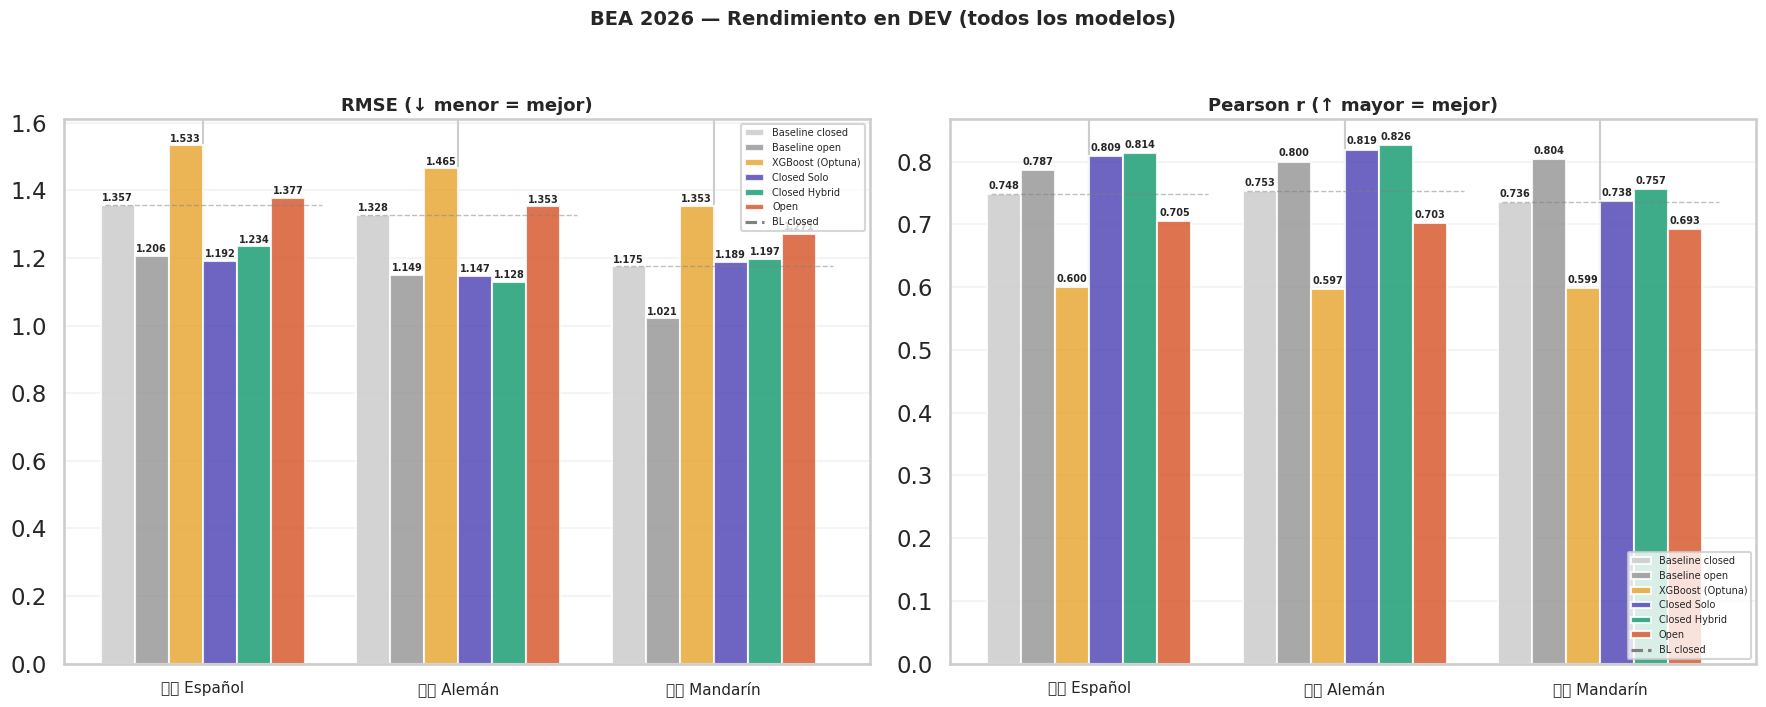

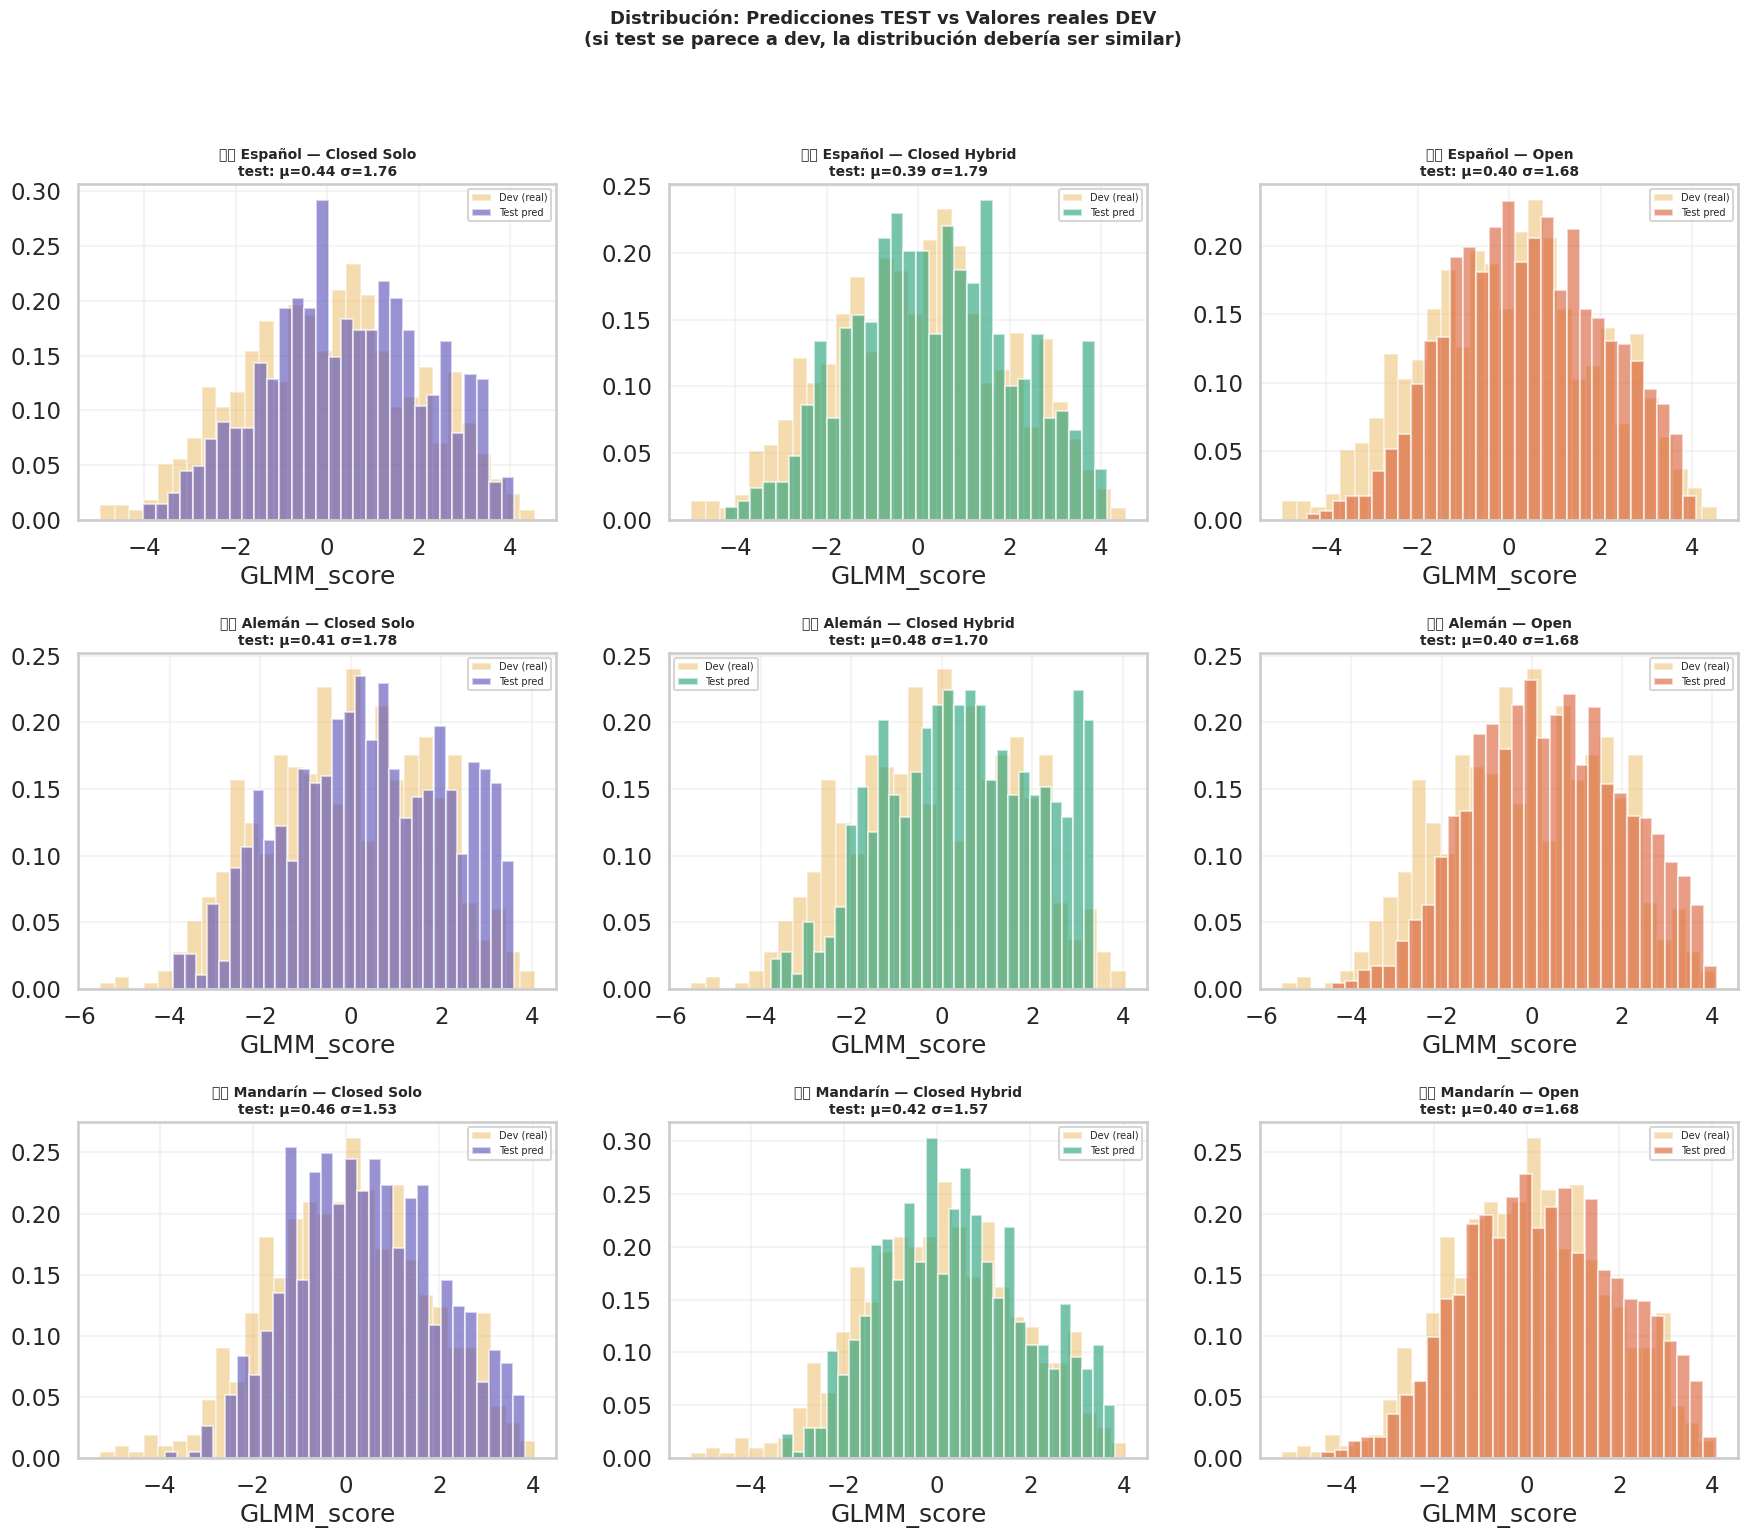


═══════════════════════════════════════════════════════════════════════════
  ESTADÍSTICAS DE PREDICCIONES EN TEST
═══════════════════════════════════════════════════════════════════════════

  🇪🇸 Español


,model,n,mean,std,min,median,max
0,DEV (real),677,0.035,1.914,-4.962,0.113,4.538
1,Closed Solo,748,0.437,1.761,-4.020,0.402,4.086
2,Closed Hybrid,748,0.388,1.793,-4.227,0.371,4.141
3,Open,2244,0.404,1.681,-4.426,0.370,4.098



  🇩🇪 Alemán


,model,n,mean,std,min,median,max
0,DEV (real),677,-0.092,1.825,-5.536,-0.034,4.061
1,Closed Solo,748,0.408,1.784,-3.920,0.406,3.602
2,Closed Hybrid,748,0.480,1.696,-3.783,0.484,3.373
3,Open,2244,0.404,1.681,-4.426,0.370,4.098



  🇨🇳 Mandarín


,model,n,mean,std,min,median,max
0,DEV (real),677,0.072,1.688,-5.272,0.100,4.039
1,Closed Solo,748,0.455,1.529,-3.873,0.423,3.844
2,Closed Hybrid,748,0.416,1.568,-3.324,0.354,3.820
3,Open,2244,0.404,1.681,-4.426,0.370,4.098



═══════════════════════════════════════════════════════════════════════════
  RECOMENDACIÓN PARA SUBMISSION (basado en DEV)
═══════════════════════════════════════════════════════════════════════════

  🇪🇸 Español:
    Mejor modelo:  Closed Solo
    RMSE:          1.1919  (baseline: 1.357)
    Pearson:       0.8086
    Mejora vs BL:  +0.1651 (✅)

  🇩🇪 Alemán:
    Mejor modelo:  Closed Hybrid
    RMSE:          1.1283  (baseline: 1.328)
    Pearson:       0.8261
    Mejora vs BL:  +0.1997 (✅)

  🇨🇳 Mandarín:
    Mejor modelo:  Closed Solo
    RMSE:          1.1892  (baseline: 1.175)
    Pearson:       0.7377
    Mejora vs BL:  -0.0142 (❌)


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# GRÁFICA FINAL — Resumen DEV + Distribución de predicciones TEST
# ══════════════════════════════════════════════════════════════════════════════
from matplotlib.lines import Line2D

# ═════════════════════════════════════════════════════════════════════════════
# A) Tabla resumen DEV — todos los modelos
# ═════════════════════════════════════════════════════════════════════════════
all_results = []
for l1 in L1S:
    all_results.append({"L1": l1, "model": "Baseline closed", **BASELINES["closed"][l1]})
    all_results.append({"L1": l1, "model": "Baseline open", **BASELINES["open"][l1]})
    if l1 in xgb_results:
        all_results.append({"L1": l1, "model": "XGBoost (Optuna)", **xgb_results[l1]})
    if l1 in solo_results:
        all_results.append({"L1": l1, "model": "Closed Solo", **solo_results[l1]})
    if l1 in hybrid_results:
        all_results.append({"L1": l1, "model": "Closed Hybrid", **hybrid_results[l1]})
    if l1 in open_results:
        all_results.append({"L1": l1, "model": "Open", **open_results[l1]})

results_df = pd.DataFrame(all_results)

print("═" * 75)
print("  RESUMEN FINAL — Rendimiento en DEV")
print("═" * 75)
for l1 in L1S:
    sub = results_df[results_df["L1"] == l1].sort_values("rmse").reset_index(drop=True)
    bl = BASELINES["closed"][l1]["rmse"]
    sub["vs BL"] = sub["rmse"].apply(lambda x: "✅" if x < bl else "")
    print(f"\n  {L1_NAMES[l1]}")
    display(sub[["model", "rmse", "pearson", "vs BL"]])

# ═════════════════════════════════════════════════════════════════════════════
# B) Gráfica comparativa DEV — RMSE + Pearson
# ═════════════════════════════════════════════════════════════════════════════
COLORS = {
    "Baseline closed": "#CCCCCC", "Baseline open": "#999999",
    "XGBoost (Optuna)": "#E8A838", "Closed Solo": "#534AB7",
    "Closed Hybrid": "#1D9E75", "Open": "#D85A30",
}
models_plot = [m for m in COLORS if m in results_df["model"].values]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, metric, title in zip(axes, ["rmse", "pearson"],
    ["RMSE (↓ menor = mejor)", "Pearson r (↑ mayor = mejor)"]):
    x = np.arange(len(L1S))
    w = 0.8 / max(len(models_plot), 1)
    for i, mn in enumerate(models_plot):
        vals = [results_df[(results_df["L1"]==l1) & (results_df["model"]==mn)][metric].values[0]
                if len(results_df[(results_df["L1"]==l1) & (results_df["model"]==mn)]) > 0 else 0
                for l1 in L1S]
        bars = ax.bar(x + i*w, vals, w, label=mn, color=COLORS[mn], alpha=0.85, edgecolor="white")
        for bar, val in zip(bars, vals):
            if val > 0:
                ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                        f"{val:.3f}", ha="center", va="bottom", fontsize=7, fontweight="bold")
    for li, l1 in enumerate(L1S):
        bl = BASELINES["closed"][l1][metric]
        ax.hlines(bl, li-0.05, li+w*len(models_plot), colors="gray", linestyles="--", linewidth=1, alpha=0.5)
    ax.set_xticks(x + w*(len(models_plot)-1)/2)
    ax.set_xticklabels([L1_NAMES[l1] for l1 in L1S], fontsize=11)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.grid(axis="y", alpha=0.2)
    h, lb = ax.get_legend_handles_labels()
    h.append(Line2D([0],[0], color="gray", linestyle="--")); lb.append("BL closed")
    ax.legend(h, lb, fontsize=7, loc="upper right" if metric=="rmse" else "lower right")

plt.suptitle("BEA 2026 — Rendimiento en DEV (todos los modelos)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "final_dev_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# ═════════════════════════════════════════════════════════════════════════════
# C) Distribución de predicciones en TEST vs distribución real en DEV
# ═════════════════════════════════════════════════════════════════════════════
test_models = {
    "Closed Solo": SUBMISSION_DIR / "closed" / "{l1}" / "predictions_closed_solo.csv",
    "Closed Hybrid": SUBMISSION_DIR / "closed" / "{l1}" / "predictions_closed_hybrid.csv",
    "Open": SUBMISSION_DIR / "open" / "{l1}" / "predictions_open.csv",
}

fig, axes = plt.subplots(len(L1S), len(test_models), figsize=(6*len(test_models), 5*len(L1S)))
if len(L1S) == 1: axes = axes.reshape(1, -1)

for row, l1 in enumerate(L1S):
    dev_true = dev_df[dev_df["L1"] == l1][TARGET].values
    for col, (mname, path_tpl) in enumerate(test_models.items()):
        ax = axes[row, col]
        # Dev true distribution
        ax.hist(dev_true, bins=30, alpha=0.4, color="#E8A838", label="Dev (real)", density=True)
        # Test predictions
        path = Path(str(path_tpl).format(l1=l1))
        if path.exists():
            test_preds = pd.read_csv(path)["GLMM_score"].values
            ax.hist(test_preds, bins=30, alpha=0.6, color=list(COLORS.values())[list(COLORS.keys()).index(mname)],
                    label=f"Test pred", density=True)
            ax.set_title(f"{L1_NAMES[l1]} — {mname}\n"
                         f"test: μ={test_preds.mean():.2f} σ={test_preds.std():.2f}",
                         fontsize=10, fontweight="bold")
        else:
            ax.set_title(f"{L1_NAMES[l1]} — {mname}\n(sin predicción)", fontsize=10)
        ax.legend(fontsize=7)
        ax.set_xlabel("GLMM_score")
        ax.grid(alpha=0.2)

plt.suptitle("Distribución: Predicciones TEST vs Valores reales DEV\n"
             "(si test se parece a dev, la distribución debería ser similar)",
             fontsize=13, fontweight="bold", y=1.03)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "test_vs_dev_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

# ═════════════════════════════════════════════════════════════════════════════
# D) Estadísticas de predicciones TEST
# ═════════════════════════════════════════════════════════════════════════════
print("\n" + "═" * 75)
print("  ESTADÍSTICAS DE PREDICCIONES EN TEST")
print("═" * 75)
stats = []
for mname, path_tpl in test_models.items():
    for l1 in L1S:
        path = Path(str(path_tpl).format(l1=l1))
        if path.exists():
            vals = pd.read_csv(path)["GLMM_score"].values
            stats.append({"model": mname, "L1": l1, "n": len(vals),
                          "mean": vals.mean(), "std": vals.std(),
                          "min": vals.min(), "median": np.median(vals), "max": vals.max()})

stats_df = pd.DataFrame(stats)
for l1 in L1S:
    print(f"\n  {L1_NAMES[l1]}")
    sub = stats_df[stats_df["L1"] == l1]
    # Agregar referencia del dev
    dev_vals = dev_df[dev_df["L1"] == l1][TARGET].values
    ref = pd.DataFrame([{"model": "DEV (real)", "L1": l1, "n": len(dev_vals),
                         "mean": dev_vals.mean(), "std": dev_vals.std(),
                         "min": dev_vals.min(), "median": np.median(dev_vals), "max": dev_vals.max()}])
    sub = pd.concat([ref, sub], ignore_index=True)
    display(sub[["model", "n", "mean", "std", "min", "median", "max"]].round(3))

# ═════════════════════════════════════════════════════════════════════════════
# E) Mejor modelo por L1 — Recomendación para submission
# ═════════════════════════════════════════════════════════════════════════════
print("\n" + "═" * 75)
print("  RECOMENDACIÓN PARA SUBMISSION (basado en DEV)")
print("═" * 75)
our_models = ["XGBoost (Optuna)", "Closed Solo", "Closed Hybrid", "Open"]
for l1 in L1S:
    sub = results_df[(results_df["L1"] == l1) & (results_df["model"].isin(our_models))]
    best = sub.sort_values("rmse").iloc[0]
    bl = BASELINES["closed"][l1]["rmse"]
    print(f"\n  {L1_NAMES[l1]}:")
    print(f"    Mejor modelo:  {best['model']}")
    print(f"    RMSE:          {best['rmse']:.4f}  (baseline: {bl})")
    print(f"    Pearson:       {best['pearson']:.4f}")
    print(f"    Mejora vs BL:  {bl - best['rmse']:+.4f} ({'✅' if best['rmse'] < bl else '❌'})")

## 14. Summary

### Trained models and where they live

| Model | File | Location | Size |
|-------|------|----------|------|
| XGBoost (Optuna) | `xgboost_optuna_{l1}.json` | Drive and GitHub | ~200 KB |
| Closed Solo | `closed_solo_{l1}.pt` | Drive only | ~1.3 GB |
| Closed Hybrid | `closed_hybrid_{l1}.pt` | Drive only | ~1.3 GB |
| Open | `open_all.pt` | Drive only | ~1.3 GB |

### For a subsequent run
1. Open this notebook in Colab.
2. Mount Drive; existing models are detected automatically.
3. Only predictions are generated (about 2 minutes).

### For local work without a GPU
1. Pull the repository to obtain predictions, XGBoost models, and results.
2. Download the .pt checkpoints from Drive only if local inference is needed.
3. Feature engineering and XGBoost refinement run on CPU.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# §15. OPEN HYBRID — xlm-roberta-base joint + features lingüísticas
#
# Idea: el baseline Open usa xlm-roberta-base joint y funciona bien (no se
# sobreajusta). Nuestras features lingüísticas aportan señal extra.
# Combinamos ambas cosas: base joint + 17 features = Open Hybrid.
# ══════════════════════════════════════════════════════════════════════════════

OPEN_BASE_NAME = "xlm-roberta-base"

# ── Hiperparámetros (basados en el baseline oficial) ─────────────────────────
OPEN_HPARAMS = {
    "batch_size": 32 if gpu_mem >= 30 else 16,
    "gradient_accumulation": 1 if gpu_mem >= 30 else 2,
    "learning_rate": 3e-5,
    "weight_decay": 0.1,
    "warmup_ratio": 0.1,
    "epochs": 5,
    "max_grad_norm": 1.0,
}

open_base_tokenizer = AutoTokenizer.from_pretrained(OPEN_BASE_NAME)

# ═════════════════════════════════════════════════════════════════════════════
# A) Entrenar con train → evaluar en dev (métricas)
# ═════════════════════════════════════════════════════════════════════════════
print(f"\n{'█' * 60}")
print(f"  OPEN HYBRID — {OPEN_BASE_NAME} joint + {len(available_features)} features")
print(f"  Train: {len(train_final)} | Dev: {len(dev_final)}")
print(f"{'█' * 60}")

ckpt = MODELS_DIR / "open_hybrid_base.pt"
preds_path = PREDICTIONS_DIR / "open_hybrid_base_dev.csv"

open_hybrid_results = {}

if ckpt.exists() and preds_path.exists():
    print("  ✓ Cargando checkpoint existente")
    pred_df = pd.read_csv(preds_path)
    merged = pred_df.merge(dev_df[["item_id", "L1", TARGET]], on="item_id")
    for l1 in L1S:
        sub = merged[merged["L1"] == l1]
        open_hybrid_results[l1] = evaluate_predictions(sub[TARGET].values, sub["prediction"].values)
else:
    print("  Entrenando desde cero...")
    train_ds = VocabDifficultyDataset(train_final, open_base_tokenizer,
                                       feature_cols=available_features, max_length=MAX_LENGTH)
    dev_ds = VocabDifficultyDataset(dev_final, open_base_tokenizer,
                                     feature_cols=available_features, max_length=MAX_LENGTH)
    train_loader = DataLoader(train_ds, batch_size=OPEN_HPARAMS["batch_size"],
                              shuffle=True, pin_memory=True)
    dev_loader = DataLoader(dev_ds, batch_size=OPEN_HPARAMS["batch_size"] * 2,
                            shuffle=False, pin_memory=True)

    model = XLMRRegressor(OPEN_BASE_NAME,
                          n_tabular_features=len(available_features)).to(DEVICE)
    print(f"  Params: {sum(p.numel() for p in model.parameters()):,}")
    print(f"  HParams: lr={OPEN_HPARAMS['learning_rate']}, wd={OPEN_HPARAMS['weight_decay']}")

    model, history = train_model(model, train_loader, dev_loader,
                                 OPEN_HPARAMS, DEVICE, tag="open_hybrid_base")

    ids, preds = predict(model, dev_loader, DEVICE)
    pred_df = pd.DataFrame({"item_id": ids.astype(int), "prediction": preds})
    pred_df.to_csv(preds_path, index=False)
    torch.save(model.state_dict(), ckpt)

    merged = pred_df.merge(dev_df[["item_id", "L1", TARGET]], on="item_id")
    for l1 in L1S:
        sub = merged[merged["L1"] == l1]
        open_hybrid_results[l1] = evaluate_predictions(sub[TARGET].values, sub["prediction"].values)

    del model, train_ds, dev_ds, train_loader, dev_loader
    gc.collect(); torch.cuda.empty_cache()

# ── Comparar vs baseline Open ────────────────────────────────────────────────
print(f"\n{'═' * 60}")
print("  OPEN HYBRID vs Baseline Open (dev)")
print(f"{'═' * 60}")
for l1 in L1S:
    m = open_hybrid_results[l1]
    bl = BASELINES["open"][l1]["rmse"]
    print(f"  {L1_NAMES[l1]}:  RMSE={m['rmse']:.4f}  Pearson={m['pearson']:.4f}  "
          f"vs BL({bl}): {'✅' if m['rmse'] < bl else '❌'}  "
          f"(Δ={bl - m['rmse']:+.4f})")

# ═════════════════════════════════════════════════════════════════════════════
# B) Reentrenar FINAL con train+dev → predecir test
# ═════════════════════════════════════════════════════════════════════════════
print(f"\n{'█' * 60}")
print(f"  OPEN HYBRID — Reentrenamiento FINAL (train+dev)")
print(f"{'█' * 60}")

ckpt_final = MODELS_DIR / "open_hybrid_base_final.pt"

if ckpt_final.exists():
    print("  ✓ _final.pt ya existe en Drive — saltando")
else:
    full_final = pd.concat([train_final, dev_final], ignore_index=True)
    print(f"  Entrenando con {len(full_final)} filas...")

    ds = VocabDifficultyDataset(full_final, open_base_tokenizer,
                                 feature_cols=available_features, max_length=MAX_LENGTH)
    loader = DataLoader(ds, batch_size=OPEN_HPARAMS["batch_size"],
                        shuffle=True, pin_memory=True)

    model = XLMRRegressor(OPEN_BASE_NAME,
                          n_tabular_features=len(available_features)).to(DEVICE)

    optimizer = torch.optim.AdamW(model.parameters(),
        lr=OPEN_HPARAMS["learning_rate"], weight_decay=OPEN_HPARAMS["weight_decay"])
    total_steps = (len(loader) * OPEN_HPARAMS["epochs"]) // OPEN_HPARAMS["gradient_accumulation"]
    warmup = int(total_steps * OPEN_HPARAMS["warmup_ratio"])
    scheduler = get_linear_schedule_with_warmup(optimizer, warmup, total_steps)
    loss_fn = nn.MSELoss()
    scaler = GradScaler()

    model.train()
    for epoch in range(OPEN_HPARAMS["epochs"]):
        losses = []
        optimizer.zero_grad()
        pbar = tqdm(loader, desc=f"  Open Hybrid Epoch {epoch+1}/{OPEN_HPARAMS['epochs']}")
        for step, batch in enumerate(pbar):
            ids = batch["input_ids"].to(DEVICE)
            mask = batch["attention_mask"].to(DEVICE)
            labels = batch["label"].to(DEVICE)
            tab = batch["tabular_features"].to(DEVICE)
            with autocast("cuda"):
                preds = model(ids, mask, tab)
                loss = loss_fn(preds, labels) / OPEN_HPARAMS["gradient_accumulation"]
            scaler.scale(loss).backward()
            if (step + 1) % OPEN_HPARAMS["gradient_accumulation"] == 0:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), OPEN_HPARAMS["max_grad_norm"])
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()
                optimizer.zero_grad()
            losses.append(loss.item() * OPEN_HPARAMS["gradient_accumulation"])
            pbar.set_postfix({"loss": f"{np.mean(losses[-50:]):.4f}"})
        print(f"    Epoch {epoch+1}: loss={np.mean(losses):.4f}")

    torch.save(model.state_dict(), ckpt_final)
    print(f"  ✓ Guardado: {ckpt_final.name}")
    del model; gc.collect(); torch.cuda.empty_cache()

# ═════════════════════════════════════════════════════════════════════════════
# C) Predecir TEST con modelo final
# ═════════════════════════════════════════════════════════════════════════════
print(f"\n{'═' * 60}")
print("  Open Hybrid (FINAL) → TEST")
print(f"{'═' * 60}")

if ckpt_final.exists() and len(test_final) > 0:
    model = XLMRRegressor(OPEN_BASE_NAME,
                          n_tabular_features=len(available_features)).to(DEVICE)
    model.load_state_dict(torch.load(ckpt_final, map_location=DEVICE, weights_only=True))

    ds = VocabDifficultyDataset(test_final, open_base_tokenizer,
                                 feature_cols=available_features, max_length=MAX_LENGTH)
    loader = DataLoader(ds, batch_size=OPEN_HPARAMS["batch_size"] * 2,
                        shuffle=False, pin_memory=True)
    ids, preds = predict(model, loader, DEVICE)

    pred_df = pd.DataFrame({"item_id": ids.astype(int), "GLMM_score": preds})
    pred_merged = pred_df.merge(test_df[["item_id", "L1"]], on="item_id")

    for l1 in L1S:
        sub = pred_merged[pred_merged["L1"] == l1][["item_id", "GLMM_score"]]
        out = SUBMISSION_DIR / "open" / l1 / "predictions_open_hybrid.csv"
        sub.to_csv(out, index=False)
        print(f"  {L1_NAMES[l1]}: {len(sub)} predicciones → {out.name}")

    del model; gc.collect(); torch.cuda.empty_cache()
    print("\n✓ Open Hybrid completado")
else:
    print("  ⚠️ Sin checkpoint final o sin datos de test")


████████████████████████████████████████████████████████████
  OPEN HYBRID — xlm-roberta-base joint + 17 features
  Train: 18273 | Dev: 2031
████████████████████████████████████████████████████████████
  Entrenando desde cero...


XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Params: 278,245,121
  HParams: lr=3e-05, wd=0.1


  Epoch 1: RMSE=1.2461 Pearson=0.7328
  ✓ Best model (RMSE=1.2461)


  Epoch 2: RMSE=1.1913 Pearson=0.7674
  ✓ Best model (RMSE=1.1913)


...

    Epoch 3: loss=0.8438


    Epoch 4: loss=0.5944


    Epoch 5: loss=0.4566
  ✓ Guardado: open_hybrid_base_final.pt

════════════════════════════════════════════════════════════
  Open Hybrid (FINAL) → TEST
════════════════════════════════════════════════════════════


XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  🇪🇸 Español: 2244 predicciones → predictions_open_hybrid.csv
  🇩🇪 Alemán: 2244 predicciones → predictions_open_hybrid.csv
  🇨🇳 Mandarín: 2244 predicciones → predictions_open_hybrid.csv

✓ Open Hybrid completado



██████████████████████████████████████████████████████████████████████
  GRID SEARCH — CLOSED SOLO — 🇪🇸 Español (6 configs)
██████████████████████████████████████████████████████████████████████

  [baseline] lr=3e-05, wd=0.1, do=0.1, ep=5


XLMRobertaModel LOAD REPORT from: xlm-roberta-large
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Epoch 1: RMSE=1.5437 Pearson=0.6052
  ✓ Best model (RMSE=1.5437)


  Epoch 2: RMSE=1.4676 Pearson=0.7181
  ✓ Best model (RMSE=1.4676)


  Epoch 3: RMSE=1.2080 Pearson=0.7806
  ✓ Best model (RMSE=1.2080)


...

,config,lr,wd,dropout,epochs,rmse,pearson
0,h_wd001_5ep,0.0,0.01,0.10,5,1.1014,0.8278
1,h_wd001,0.0,0.01,0.10,3,1.1527,0.8249
2,h_wd05_5ep,0.0,0.05,0.10,5,1.1541,0.8282
3,h_baseline,0.0,0.10,0.10,3,1.1589,0.8325
4,h_do15_5ep,0.0,0.10,0.15,5,1.1836,0.8271



  🇨🇳 Mandarín — Closed Solo:
    Mejor: [wd001_8ep] lr=2e-05, wd=0.01, do=0.1, ep=8
    RMSE:  1.0217  (actual: 1.1892)  ✅ MEJORA
    Pearson: 0.8006  ✅ supera BL
    Todas las configs:


,config,lr,wd,dropout,epochs,rmse,pearson
0,wd001_8ep,0.0,0.01,0.10,8,1.0217,0.8006
1,do15_8ep,0.0,0.10,0.15,8,1.0229,0.8160
2,lr1e5_wd05_10ep,0.0,0.05,0.10,10,1.0495,0.8102
3,wd001,0.0,0.01,0.10,5,1.1159,0.8142
4,lr2e5,0.0,0.10,0.10,5,1.6878,0.0415
5,baseline,0.0,0.10,0.10,5,1.6882,0.0927



  🇨🇳 Mandarín — Closed Hybrid:
    Mejor: [h_wd05_5ep] lr=1e-05, wd=0.05, do=0.1, ep=5
    RMSE:  1.0190  (actual: 1.1966)  ✅ MEJORA
    Pearson: 0.8089  ✅ supera BL
    Todas las configs:


,config,lr,wd,dropout,epochs,rmse,pearson
0,h_wd05_5ep,0.0,0.05,0.10,5,1.0190,0.8089
1,h_wd001_5ep,0.0,0.01,0.10,5,1.0309,0.8101
2,h_baseline,0.0,0.10,0.10,3,1.0704,0.8068
3,h_wd001,0.0,0.01,0.10,3,1.0813,0.7917
4,h_do15_5ep,0.0,0.10,0.15,5,1.0826,0.8061


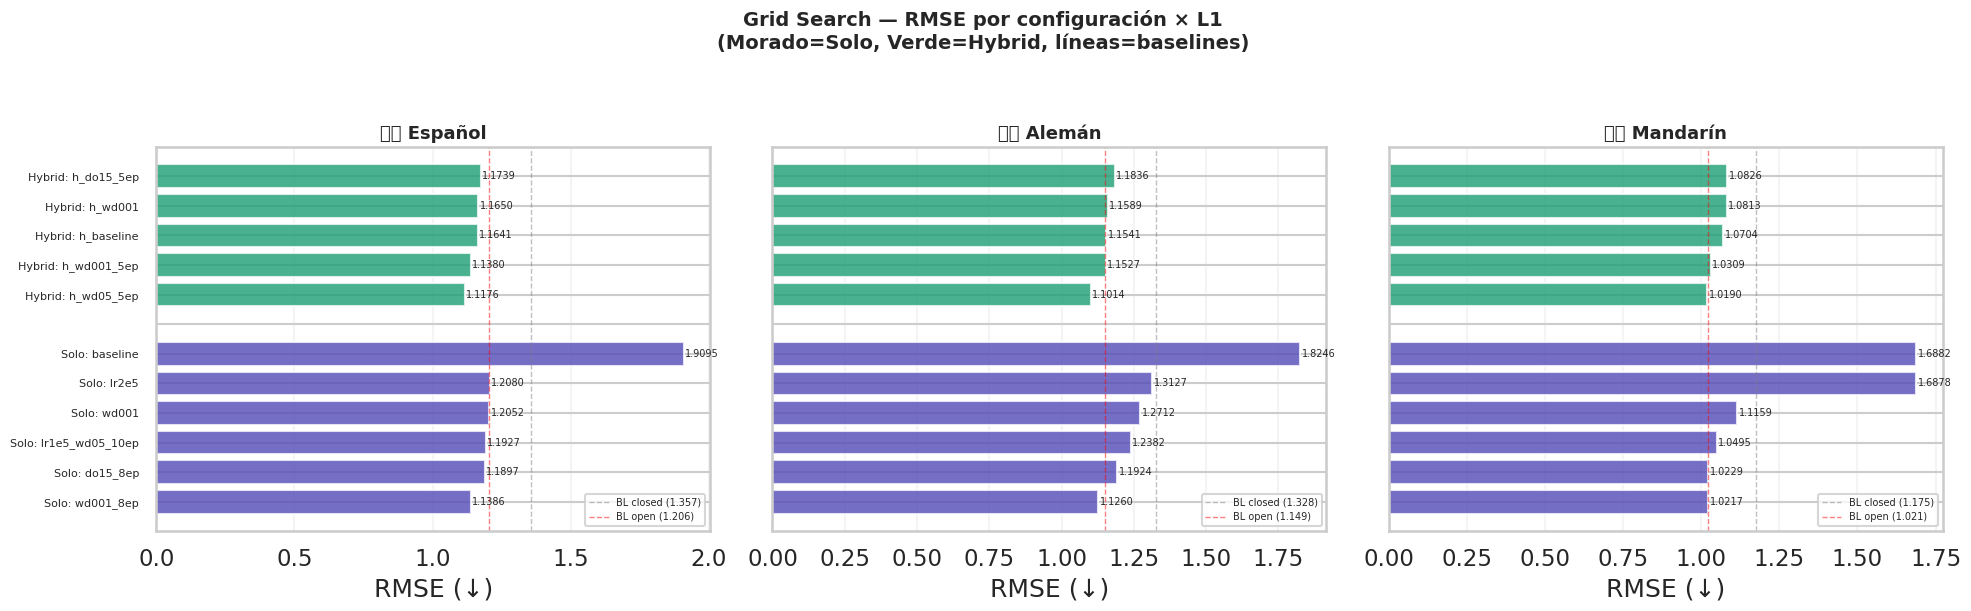

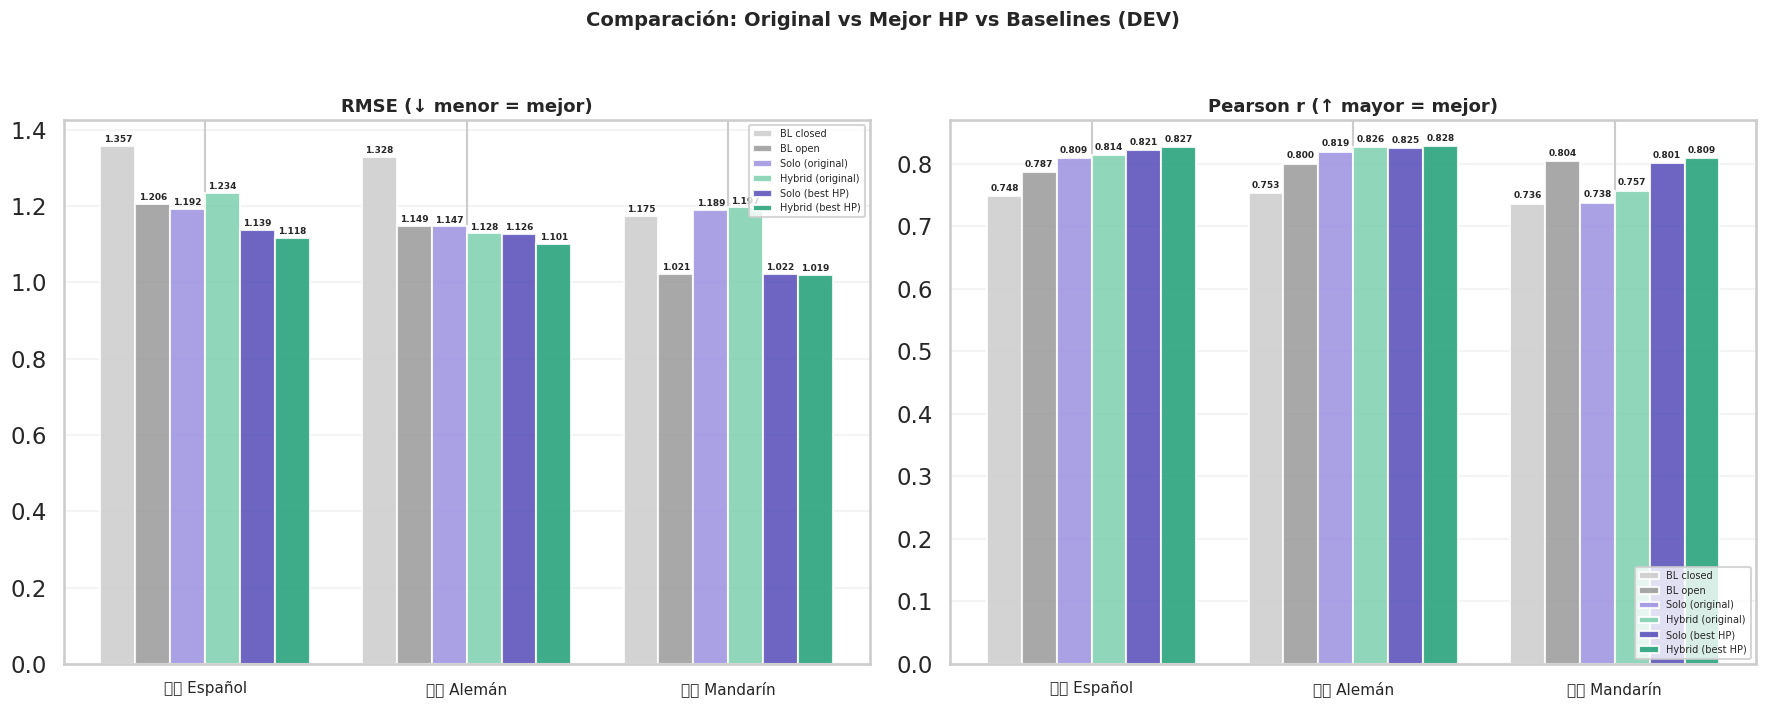


██████████████████████████████████████████████████████████████████████
  REENTRENAMIENTO FINAL — Solo con configs que mejoraron
██████████████████████████████████████████████████████████████████████

  🇪🇸 Español solo: MEJORA 1.1919 → 1.1386 (+0.0532)
  Config: [wd001_8ep] → Reentrenando con train+dev...


XLMRobertaModel LOAD REPORT from: xlm-roberta-large
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


    Epoch 1: loss=3.3476


    Epoch 2: loss=2.2138


    Epoch 3: loss=1.4523


...

    Epoch 2: loss=0.2532


    Epoch 3: loss=0.1970


    Epoch 4: loss=0.1577


    Epoch 5: loss=0.1398


  ✓ Guardado: hp_hybrid_cn_best_final.pt + predictions_hp_hybrid.csv

══════════════════════════════════════════════════════════════════════
  RESUMEN — Qué mandar en el submission
══════════════════════════════════════════════════════════════════════

  🇪🇸 Español:
    → MANDAR: predictions_hp_hybrid.csv
    → Modelo: Hybrid (best HP)
    → RMSE:   1.1176  vs BL(1.357): +0.2394 ✅
      alt: predictions_hp_solo.csv (Solo (best HP), RMSE=1.1386)
      alt: predictions_closed_solo.csv (Solo (original), RMSE=1.1919)
      alt: predictions_closed_hybrid.csv (Hybrid (original), RMSE=1.2345)

  🇩🇪 Alemán:
    → MANDAR: predictions_hp_hybrid.csv
    → Modelo: Hybrid (best HP)
    → RMSE:   1.1014  vs BL(1.328): +0.2266 ✅
      alt: predictions_hp_solo.csv (Solo (best HP), RMSE=1.1260)
      alt: predictions_closed_hybrid.csv (Hybrid (original), RMSE=1.1283)
      alt: predictions_closed_solo.csv (Solo (original), RMSE=1.1466)

  🇨🇳 Mandarín:
    → MANDAR: predictions_hp_hybrid.csv
    → Model

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# §17. BÚSQUEDA DE HIPERPARÁMETROS — Closed Solo + Hybrid (todos los L1s)
#
# Grid search por L1 × modelo. Cada combinación entrena con train → eval dev.
# Si mejora, guarda modelo y genera predicción de test.
# Al final: tabla comparativa + gráficas.
# ══════════════════════════════════════════════════════════════════════════════

# ── Configuraciones a probar ─────────────────────────────────────────────────
SEARCH_CONFIGS = [
    {"lr": 3e-5, "wd": 0.1,  "dropout": 0.1,  "epochs": 5,  "tag": "baseline"},
    {"lr": 2e-5, "wd": 0.01, "dropout": 0.1,  "epochs": 5,  "tag": "wd001"},
    {"lr": 2e-5, "wd": 0.1,  "dropout": 0.1,  "epochs": 5,  "tag": "lr2e5"},
    {"lr": 2e-5, "wd": 0.01, "dropout": 0.1,  "epochs": 8,  "tag": "wd001_8ep"},
    {"lr": 3e-5, "wd": 0.1,  "dropout": 0.15, "epochs": 8,  "tag": "do15_8ep"},
    {"lr": 1e-5, "wd": 0.05, "dropout": 0.1,  "epochs": 10, "tag": "lr1e5_wd05_10ep"},
]

# Hiperparámetros para Hybrid (warm-start, lr más bajo)
HYBRID_CONFIGS = [
    {"lr": 1e-5, "wd": 0.1,  "dropout": 0.1,  "epochs": 3, "tag": "h_baseline"},
    {"lr": 5e-6, "wd": 0.01, "dropout": 0.1,  "epochs": 3, "tag": "h_wd001"},
    {"lr": 1e-5, "wd": 0.01, "dropout": 0.1,  "epochs": 5, "tag": "h_wd001_5ep"},
    {"lr": 5e-6, "wd": 0.1,  "dropout": 0.15, "epochs": 5, "tag": "h_do15_5ep"},
    {"lr": 1e-5, "wd": 0.05, "dropout": 0.1,  "epochs": 5, "tag": "h_wd05_5ep"},
]

hp_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

all_hp_results = []  # almacena TODOS los resultados

# ═════════════════════════════════════════════════════════════════════════════
# CLOSED SOLO — Grid search por L1
# ═════════════════════════════════════════════════════════════════════════════
for l1 in L1S:
    tr = train_df[train_df["L1"] == l1]
    dv = dev_df[dev_df["L1"] == l1]

    print(f"\n{'█' * 70}")
    print(f"  GRID SEARCH — CLOSED SOLO — {L1_NAMES[l1]} ({len(SEARCH_CONFIGS)} configs)")
    print(f"{'█' * 70}")

    for cfg in SEARCH_CONFIGS:
        run_tag = f"solo_{l1}_{cfg['tag']}"
        preds_path = PREDICTIONS_DIR / f"hp_{run_tag}_dev.csv"

        if preds_path.exists():
            pred_df = pd.read_csv(preds_path)
            dv_idx = dv.set_index("item_id")
            y_true = dv_idx.loc[pred_df["item_id"].values][TARGET].values
            m = evaluate_predictions(y_true, pred_df["prediction"].values)
            m.update({"L1": l1, "model": "Closed Solo", "config": cfg["tag"],
                       **{k: v for k, v in cfg.items() if k != "tag"}})
            all_hp_results.append(m)
            print(f"  [{cfg['tag']}] ✓ existe — RMSE={m['rmse']:.4f} Pearson={m['pearson']:.4f}")
            continue

        print(f"\n  [{cfg['tag']}] lr={cfg['lr']}, wd={cfg['wd']}, do={cfg['dropout']}, ep={cfg['epochs']}")

        hparams = {
            "batch_size": HPARAMS["batch_size"],
            "gradient_accumulation": HPARAMS["gradient_accumulation"],
            "learning_rate": cfg["lr"],
            "weight_decay": cfg["wd"],
            "warmup_ratio": 0.1,
            "epochs": cfg["epochs"],
            "max_grad_norm": 1.0,
        }

        train_ds = VocabDifficultyDataset(tr, hp_tokenizer, max_length=MAX_LENGTH)
        dev_ds = VocabDifficultyDataset(dv, hp_tokenizer, max_length=MAX_LENGTH)
        train_loader = DataLoader(train_ds, batch_size=hparams["batch_size"],
                                  shuffle=True, pin_memory=True)
        dev_loader = DataLoader(dev_ds, batch_size=hparams["batch_size"] * 2,
                                shuffle=False, pin_memory=True)

        model = XLMRRegressor(MODEL_NAME, 0, dropout=cfg["dropout"]).to(DEVICE)
        model, history = train_model(model, train_loader, dev_loader,
                                     hparams, DEVICE, tag=run_tag)

        ids, preds = predict(model, dev_loader, DEVICE)
        dv_idx = dv.set_index("item_id")
        y_true = dv_idx.loc[ids][TARGET].values
        m = evaluate_predictions(y_true, preds)
        m.update({"L1": l1, "model": "Closed Solo", "config": cfg["tag"],
                   **{k: v for k, v in cfg.items() if k != "tag"}})
        all_hp_results.append(m)

        pd.DataFrame({"item_id": ids.astype(int), "prediction": preds}).to_csv(
            preds_path, index=False)

        # Guardar temporalmente el mejor por L1
        l1_results = [r for r in all_hp_results if r["L1"] == l1 and r["model"] == "Closed Solo"]
        best = min(l1_results, key=lambda x: x["rmse"])
        if m["rmse"] == best["rmse"]:
            torch.save(model.state_dict(), MODELS_DIR / f"hp_solo_{l1}_best.pt")
            print(f"  ⭐ Mejor Solo {l1}: RMSE={m['rmse']:.4f}")

        del model, train_ds, dev_ds, train_loader, dev_loader
        gc.collect(); torch.cuda.empty_cache()

# ═════════════════════════════════════════════════════════════════════════════
# CLOSED HYBRID — Grid search por L1 (warm-start desde mejor Solo)
# ═════════════════════════════════════════════════════════════════════════════
for l1 in L1S:
    tr_f = train_final[train_final["L1"] == l1]
    dv_f = dev_final[dev_final["L1"] == l1]

    # Cargar mejor Solo para warm-start
    best_solo_path = MODELS_DIR / f"hp_solo_{l1}_best.pt"
    if not best_solo_path.exists():
        # Fallback al modelo original
        best_solo_path = MODELS_DIR / f"closed_solo_{l1}.pt"
    if not best_solo_path.exists():
        print(f"  ⚠️ {l1}: sin modelo Solo para warm-start — saltando Hybrid")
        continue

    solo_state = torch.load(best_solo_path, map_location="cpu", weights_only=True)
    solo_transformer = {k: v for k, v in solo_state.items() if k.startswith("transformer.")}
    del solo_state

    print(f"\n{'█' * 70}")
    print(f"  GRID SEARCH — CLOSED HYBRID — {L1_NAMES[l1]} ({len(HYBRID_CONFIGS)} configs)")
    print(f"  Warm-start desde: {best_solo_path.name}")
    print(f"{'█' * 70}")

    for cfg in HYBRID_CONFIGS:
        run_tag = f"hybrid_{l1}_{cfg['tag']}"
        preds_path = PREDICTIONS_DIR / f"hp_{run_tag}_dev.csv"

        if preds_path.exists():
            pred_df = pd.read_csv(preds_path)
            dv_idx = dv_f.set_index("item_id")
            y_true = dv_idx.loc[pred_df["item_id"].values][TARGET].values
            m = evaluate_predictions(y_true, pred_df["prediction"].values)
            m.update({"L1": l1, "model": "Closed Hybrid", "config": cfg["tag"],
                       **{k: v for k, v in cfg.items() if k != "tag"}})
            all_hp_results.append(m)
            print(f"  [{cfg['tag']}] ✓ existe — RMSE={m['rmse']:.4f} Pearson={m['pearson']:.4f}")
            continue

        print(f"\n  [{cfg['tag']}] lr={cfg['lr']}, wd={cfg['wd']}, do={cfg['dropout']}, ep={cfg['epochs']}")

        hparams = {
            "batch_size": HPARAMS["batch_size"],
            "gradient_accumulation": HPARAMS["gradient_accumulation"],
            "learning_rate": cfg["lr"],
            "weight_decay": cfg["wd"],
            "warmup_ratio": 0.1,
            "epochs": cfg["epochs"],
            "max_grad_norm": 1.0,
        }

        train_ds = VocabDifficultyDataset(tr_f, hp_tokenizer,
                                           feature_cols=available_features, max_length=MAX_LENGTH)
        dev_ds = VocabDifficultyDataset(dv_f, hp_tokenizer,
                                         feature_cols=available_features, max_length=MAX_LENGTH)
        train_loader = DataLoader(train_ds, batch_size=hparams["batch_size"],
                                  shuffle=True, pin_memory=True)
        dev_loader = DataLoader(dev_ds, batch_size=hparams["batch_size"] * 2,
                                shuffle=False, pin_memory=True)

        model = XLMRRegressor(MODEL_NAME, len(available_features),
                              dropout=cfg["dropout"]).to(DEVICE)
        model.load_state_dict(solo_transformer, strict=False)

        model, history = train_model(model, train_loader, dev_loader,
                                     hparams, DEVICE, tag=run_tag)

        ids, preds = predict(model, dev_loader, DEVICE)
        dv_idx = dv_f.set_index("item_id")
        y_true = dv_idx.loc[ids][TARGET].values
        m = evaluate_predictions(y_true, preds)
        m.update({"L1": l1, "model": "Closed Hybrid", "config": cfg["tag"],
                   **{k: v for k, v in cfg.items() if k != "tag"}})
        all_hp_results.append(m)

        pd.DataFrame({"item_id": ids.astype(int), "prediction": preds}).to_csv(
            preds_path, index=False)

        l1_results = [r for r in all_hp_results if r["L1"] == l1 and r["model"] == "Closed Hybrid"]
        best = min(l1_results, key=lambda x: x["rmse"])
        if m["rmse"] == best["rmse"]:
            torch.save(model.state_dict(), MODELS_DIR / f"hp_hybrid_{l1}_best.pt")
            print(f"  ⭐ Mejor Hybrid {l1}: RMSE={m['rmse']:.4f}")

        del model, train_ds, dev_ds, train_loader, dev_loader
        gc.collect(); torch.cuda.empty_cache()

    del solo_transformer; gc.collect()

# ═════════════════════════════════════════════════════════════════════════════
# RESULTADOS — Tabla + Gráficas
# ═════════════════════════════════════════════════════════════════════════════
hp_df = pd.DataFrame(all_hp_results)

# ── Tabla: mejor config por L1 × modelo ──────────────────────────────────────
print(f"\n{'═' * 80}")
print("  MEJORES CONFIGURACIONES POR L1 × MODELO")
print(f"{'═' * 80}")

best_configs = {}
for l1 in L1S:
    for mtype in ["Closed Solo", "Closed Hybrid"]:
        sub = hp_df[(hp_df["L1"] == l1) & (hp_df["model"] == mtype)]
        if len(sub) == 0:
            continue
        sub = sub.sort_values("rmse").reset_index(drop=True)
        best = sub.iloc[0]
        key = f"{mtype}_{l1}"
        best_configs[key] = best

        # Comparar vs modelo actual
        if mtype == "Closed Solo":
            current = solo_results.get(l1, {}).get("rmse", 999)
        else:
            current = hybrid_results.get(l1, {}).get("rmse", 999)
        bl = BASELINES["closed"][l1]["rmse"]

        improved = "✅ MEJORA" if best["rmse"] < current else "❌ no mejora"
        vs_bl = "✅ supera BL" if best["rmse"] < bl else ""

        print(f"\n  {L1_NAMES[l1]} — {mtype}:")
        print(f"    Mejor: [{best['config']}] lr={best['lr']}, wd={best['wd']}, "
              f"do={best['dropout']}, ep={int(best['epochs'])}")
        print(f"    RMSE:  {best['rmse']:.4f}  (actual: {current:.4f})  {improved}")
        print(f"    Pearson: {best['pearson']:.4f}  {vs_bl}")

        print(f"    Todas las configs:")
        display(sub[["config", "lr", "wd", "dropout", "epochs", "rmse", "pearson"]].round(4))

# ── Gráfica 1: RMSE por config × L1 (Solo) ──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

for ax, l1 in zip(axes, L1S):
    sub_solo = hp_df[(hp_df["L1"] == l1) & (hp_df["model"] == "Closed Solo")].sort_values("rmse")
    sub_hybrid = hp_df[(hp_df["L1"] == l1) & (hp_df["model"] == "Closed Hybrid")].sort_values("rmse")

    y_pos = np.arange(len(sub_solo) + len(sub_hybrid) + 1)  # +1 for separator
    labels = []
    values = []
    colors = []

    for _, row in sub_solo.iterrows():
        labels.append(f"Solo: {row['config']}")
        values.append(row["rmse"])
        colors.append("#534AB7")

    labels.append("")
    values.append(0)
    colors.append("white")

    for _, row in sub_hybrid.iterrows():
        labels.append(f"Hybrid: {row['config']}")
        values.append(row["rmse"])
        colors.append("#1D9E75")

    bars = ax.barh(y_pos, values, color=colors, alpha=0.8, edgecolor="white")
    for bar, val in zip(bars, values):
        if val > 0:
            ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
                    f"{val:.4f}", va="center", fontsize=7)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_title(f"{L1_NAMES[l1]}", fontsize=13, fontweight="bold")
    ax.set_xlabel("RMSE (↓)")

    # Líneas de referencia
    bl_c = BASELINES["closed"][l1]["rmse"]
    bl_o = BASELINES["open"][l1]["rmse"]
    ax.axvline(bl_c, color="gray", linestyle="--", linewidth=1, alpha=0.5, label=f"BL closed ({bl_c})")
    ax.axvline(bl_o, color="red", linestyle="--", linewidth=1, alpha=0.5, label=f"BL open ({bl_o})")
    ax.legend(fontsize=7, loc="lower right")
    ax.grid(axis="x", alpha=0.2)

plt.suptitle("Grid Search — RMSE por configuración × L1\n(Morado=Solo, Verde=Hybrid, líneas=baselines)",
             fontsize=14, fontweight="bold", y=1.03)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "hp_grid_search_rmse.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Gráfica 2: Comparación mejor HP vs original vs baseline ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

comparison_rows = []
for l1 in L1S:
    comparison_rows.append({"L1": l1, "model": "BL closed", "rmse": BASELINES["closed"][l1]["rmse"],
                             "pearson": BASELINES["closed"][l1]["pearson"]})
    comparison_rows.append({"L1": l1, "model": "BL open", "rmse": BASELINES["open"][l1]["rmse"],
                             "pearson": BASELINES["open"][l1]["pearson"]})
    if l1 in solo_results:
        comparison_rows.append({"L1": l1, "model": "Solo (original)", **solo_results[l1]})
    if l1 in hybrid_results:
        comparison_rows.append({"L1": l1, "model": "Hybrid (original)", **hybrid_results[l1]})

    key_s = f"Closed Solo_{l1}"
    if key_s in best_configs:
        b = best_configs[key_s]
        comparison_rows.append({"L1": l1, "model": f"Solo (best HP)", "rmse": b["rmse"], "pearson": b["pearson"]})
    key_h = f"Closed Hybrid_{l1}"
    if key_h in best_configs:
        b = best_configs[key_h]
        comparison_rows.append({"L1": l1, "model": f"Hybrid (best HP)", "rmse": b["rmse"], "pearson": b["pearson"]})

comp_df = pd.DataFrame(comparison_rows)

COMP_COLORS = {
    "BL closed": "#CCCCCC", "BL open": "#999999",
    "Solo (original)": "#9B8FE0", "Hybrid (original)": "#7CCFAE",
    "Solo (best HP)": "#534AB7", "Hybrid (best HP)": "#1D9E75",
}
comp_models = [m for m in COMP_COLORS if m in comp_df["model"].values]

for ax, metric, title in zip(axes, ["rmse", "pearson"],
    ["RMSE (↓ menor = mejor)", "Pearson r (↑ mayor = mejor)"]):

    x = np.arange(len(L1S))
    w = 0.8 / max(len(comp_models), 1)

    for i, mn in enumerate(comp_models):
        vals = []
        for l1 in L1S:
            row = comp_df[(comp_df["L1"] == l1) & (comp_df["model"] == mn)]
            vals.append(row[metric].values[0] if len(row) > 0 else 0)
        bars = ax.bar(x + i*w, vals, w, label=mn, color=COMP_COLORS[mn],
                      alpha=0.85, edgecolor="white")
        for bar, val in zip(bars, vals):
            if val > 0:
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                        f"{val:.3f}", ha="center", va="bottom", fontsize=6.5, fontweight="bold")

    ax.set_xticks(x + w * (len(comp_models) - 1) / 2)
    ax.set_xticklabels([L1_NAMES[l1] for l1 in L1S], fontsize=11)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.grid(axis="y", alpha=0.2)
    ax.legend(fontsize=7, loc="upper right" if metric == "rmse" else "lower right")

plt.suptitle("Comparación: Original vs Mejor HP vs Baselines (DEV)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "hp_original_vs_best.png", dpi=150, bbox_inches="tight")
plt.show()

# ═════════════════════════════════════════════════════════════════════════════
# Si hay mejora → reentrenar FINAL (train+dev) y predecir test
# ═════════════════════════════════════════════════════════════════════════════
print(f"\n{'█' * 70}")
print("  REENTRENAMIENTO FINAL — Solo con configs que mejoraron")
print(f"{'█' * 70}")

for l1 in L1S:
    for mtype, configs, orig_results in [
        ("solo", SEARCH_CONFIGS, solo_results),
        ("hybrid", HYBRID_CONFIGS, hybrid_results)
    ]:
        key = f"Closed {'Solo' if mtype == 'solo' else 'Hybrid'}_{l1}"
        if key not in best_configs:
            continue

        best = best_configs[key]
        current = orig_results.get(l1, {}).get("rmse", 999)

        if best["rmse"] >= current:
            print(f"\n  {L1_NAMES[l1]} {mtype}: no mejora ({best['rmse']:.4f} >= {current:.4f}) — skip")
            continue

        ckpt_final = MODELS_DIR / f"hp_{mtype}_{l1}_best_final.pt"
        test_pred_path = SUBMISSION_DIR / "closed" / l1 / f"predictions_hp_{mtype}.csv"

        if ckpt_final.exists() and test_pred_path.exists():
            print(f"\n  {L1_NAMES[l1]} {mtype}: ✓ _final.pt ya existe")
            continue

        print(f"\n  {L1_NAMES[l1]} {mtype}: MEJORA {current:.4f} → {best['rmse']:.4f} ({current-best['rmse']:+.4f})")
        print(f"  Config: [{best['config']}] → Reentrenando con train+dev...")

        if mtype == "solo":
            full_data = pd.concat([train_df[train_df["L1"] == l1],
                                    dev_df[dev_df["L1"] == l1]], ignore_index=True)
            feat_cols = None
            n_feat = 0
        else:
            full_data = pd.concat([train_final[train_final["L1"] == l1],
                                    dev_final[dev_final["L1"] == l1]], ignore_index=True)
            feat_cols = available_features
            n_feat = len(available_features)

        ds = VocabDifficultyDataset(full_data, hp_tokenizer,
                                     feature_cols=feat_cols, max_length=MAX_LENGTH)
        loader = DataLoader(ds, batch_size=HPARAMS["batch_size"], shuffle=True, pin_memory=True)

        model = XLMRRegressor(MODEL_NAME, n_feat, dropout=best["dropout"]).to(DEVICE)

        # Para hybrid: warm-start desde el mejor solo final
        if mtype == "hybrid":
            solo_final_path = MODELS_DIR / f"hp_solo_{l1}_best_final.pt"
            if not solo_final_path.exists():
                solo_final_path = MODELS_DIR / f"closed_solo_{l1}_final.pt"
            if solo_final_path.exists():
                s = torch.load(solo_final_path, map_location=DEVICE, weights_only=True)
                model.load_state_dict({k: v for k, v in s.items() if k.startswith("transformer.")},
                                      strict=False)
                del s
                print(f"  ✓ Warm-start desde {solo_final_path.name}")

        final_hparams = {
            "batch_size": HPARAMS["batch_size"],
            "gradient_accumulation": HPARAMS["gradient_accumulation"],
            "learning_rate": best["lr"],
            "weight_decay": best["wd"],
            "warmup_ratio": 0.1,
            "epochs": int(best["epochs"]),
            "max_grad_norm": 1.0,
        }

        optimizer = torch.optim.AdamW(model.parameters(),
            lr=final_hparams["learning_rate"], weight_decay=final_hparams["weight_decay"])
        total_steps = (len(loader) * final_hparams["epochs"]) // final_hparams["gradient_accumulation"]
        warmup = int(total_steps * final_hparams["warmup_ratio"])
        scheduler = get_linear_schedule_with_warmup(optimizer, warmup, total_steps)
        loss_fn = nn.MSELoss()
        scaler = GradScaler()

        model.train()
        for epoch in range(final_hparams["epochs"]):
            losses = []
            optimizer.zero_grad()
            pbar = tqdm(loader, desc=f"  {l1} {mtype} Epoch {epoch+1}/{final_hparams['epochs']}")
            for step, batch in enumerate(pbar):
                input_ids = batch["input_ids"].to(DEVICE)
                mask = batch["attention_mask"].to(DEVICE)
                labels = batch["label"].to(DEVICE)
                tab = batch.get("tabular_features")
                if tab is not None:
                    tab = tab.to(DEVICE)
                with autocast("cuda"):
                    p = model(input_ids, mask, tab)
                    loss = loss_fn(p, labels) / final_hparams["gradient_accumulation"]
                scaler.scale(loss).backward()
                if (step + 1) % final_hparams["gradient_accumulation"] == 0:
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), final_hparams["max_grad_norm"])
                    scaler.step(optimizer)
                    scaler.update()
                    scheduler.step()
                    optimizer.zero_grad()
                losses.append(loss.item() * final_hparams["gradient_accumulation"])
                pbar.set_postfix({"loss": f"{np.mean(losses[-50:]):.4f}"})
            print(f"    Epoch {epoch+1}: loss={np.mean(losses):.4f}")

        torch.save(model.state_dict(), ckpt_final)

        # Predecir test
        if mtype == "solo":
            ts = test_df[test_df["L1"] == l1]
            ts_ds = VocabDifficultyDataset(ts, hp_tokenizer, max_length=MAX_LENGTH)
        else:
            ts = test_final[test_final["L1"] == l1]
            ts_ds = VocabDifficultyDataset(ts, hp_tokenizer,
                                            feature_cols=available_features, max_length=MAX_LENGTH)

        ts_loader = DataLoader(ts_ds, batch_size=HPARAMS["batch_size"] * 2,
                               shuffle=False, pin_memory=True)
        ids, preds = predict(model, ts_loader, DEVICE)
        pd.DataFrame({"item_id": ids.astype(int), "GLMM_score": preds}).to_csv(
            test_pred_path, index=False)
        print(f"  ✓ Guardado: {ckpt_final.name} + {test_pred_path.name}")

        del model; gc.collect(); torch.cuda.empty_cache()

# ── Resumen final ────────────────────────────────────────────────────────────
print(f"\n{'═' * 70}")
print("  RESUMEN — Qué mandar en el submission")
print(f"{'═' * 70}")

for l1 in L1S:
    candidates = []
    # Originales
    if l1 in solo_results:
        candidates.append(("Solo (original)", solo_results[l1]["rmse"], "predictions_closed_solo.csv"))
    if l1 in hybrid_results:
        candidates.append(("Hybrid (original)", hybrid_results[l1]["rmse"], "predictions_closed_hybrid.csv"))
    # HP search
    for mtype in ["solo", "hybrid"]:
        path = SUBMISSION_DIR / "closed" / l1 / f"predictions_hp_{mtype}.csv"
        key = f"Closed {'Solo' if mtype == 'solo' else 'Hybrid'}_{l1}"
        if path.exists() and key in best_configs:
            candidates.append((f"{'Solo' if mtype == 'solo' else 'Hybrid'} (best HP)",
                               best_configs[key]["rmse"], path.name))

    candidates.sort(key=lambda x: x[1])
    best_name, best_rmse, best_file = candidates[0]
    bl = BASELINES["closed"][l1]["rmse"]

    print(f"\n  {L1_NAMES[l1]}:")
    print(f"    → MANDAR: {best_file}")
    print(f"    → Modelo: {best_name}")
    print(f"    → RMSE:   {best_rmse:.4f}  vs BL({bl}): {bl-best_rmse:+.4f} "
          f"{'✅' if best_rmse < bl else '❌'}")
    for name, rmse_val, fname in candidates[1:]:
        print(f"      alt: {fname} ({name}, RMSE={rmse_val:.4f})")

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# §18. CIERRE — Verificar modelos, regenerar ZIP, inventario final
# ══════════════════════════════════════════════════════════════════════════════
import zipfile, shutil

# ═════════════════════════════════════════════════════════════════════════════
# A) Inventario de TODOS los archivos en Drive
# ═════════════════════════════════════════════════════════════════════════════
print("═" * 70)
print("  INVENTARIO — Modelos en Drive")
print("═" * 70)

total_size = 0
for subdir in ["models", "predictions", "results", "features", "embeddings", "submission"]:
    d = DRIVE_PROJECT / subdir
    if not d.exists():
        continue
    files = sorted([f for f in d.rglob("*") if f.is_file()])
    dir_size = sum(f.stat().st_size for f in files)
    total_size += dir_size
    print(f"\n  📁 {subdir}/ ({dir_size/1e6:.1f} MB, {len(files)} archivos)")
    for f in files:
        size = f.stat().st_size
        unit = "MB" if size > 1e6 else "KB"
        val = size/1e6 if size > 1e6 else size/1e3
        print(f"      {f.name:50s} {val:8.1f} {unit}")

print(f"\n  TOTAL: {total_size/1e9:.2f} GB")

# ═════════════════════════════════════════════════════════════════════════════
# B) Regenerar ZIP con los MEJORES archivos
# ═════════════════════════════════════════════════════════════════════════════
print(f"\n{'═' * 70}")
print("  GENERANDO ZIP FINAL")
print(f"{'═' * 70}")

# Definir qué archivo mandar por cada L1 (hasta 3 runs)
SUBMISSION_PLAN = {
    "closed": {
        "es": [
            "predictions_hp_hybrid.csv",      # run 1: mejor
            "predictions_hp_solo.csv",         # run 2: segundo mejor
            "predictions_closed_solo.csv",     # run 3: original
        ],
        "de": [
            "predictions_hp_hybrid.csv",
            "predictions_hp_solo.csv",
            "predictions_closed_hybrid.csv",
        ],
        "cn": [
            "predictions_hp_hybrid.csv",
            "predictions_hp_solo.csv",
            "predictions_closed_solo.csv",
        ],
    },
}

zip_path = SUBMISSION_DIR / "submission_final.zip"

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for track, l1s in SUBMISSION_PLAN.items():
        for l1, files in l1s.items():
            for fname in files:
                src = SUBMISSION_DIR / track / l1 / fname
                if src.exists():
                    arcname = f"{track}/{l1}/{fname}"
                    zf.write(src, arcname)
                    print(f"  ✅ {arcname}")
                else:
                    print(f"  ⚠️  NO ENCONTRADO: {track}/{l1}/{fname}")

print(f"\n✓ ZIP: {zip_path}")
print(f"  Tamaño: {zip_path.stat().st_size / 1024:.1f} KB")

# Verificar contenido
print(f"\nContenido del ZIP:")
with zipfile.ZipFile(zip_path, "r") as zf:
    for info in zf.infolist():
        # Verificar formato
        import io, csv
        with zf.open(info.filename) as f:
            reader = csv.reader(io.TextIOWrapper(f))
            header = next(reader)
            n_rows = sum(1 for _ in reader)
        print(f"  {info.filename:55s} cols={header} rows={n_rows}")

# ═════════════════════════════════════════════════════════════════════════════
# C) Copiar al repo (para git push)
# ═════════════════════════════════════════════════════════════════════════════
print(f"\n{'═' * 70}")
print("  COPIANDO AL REPO")
print(f"{'═' * 70}")

REPO_DIRS = {
    "results": REPO_DIR / "bea2026st" / "results",
    "predictions": REPO_DIR / "bea2026st" / "predictions",
    "models": REPO_DIR / "bea2026st" / "models",
    "submission": REPO_DIR / "bea2026st" / "submission",
}

for name, dest in REPO_DIRS.items():
    dest.mkdir(parents=True, exist_ok=True)

# Resultados y gráficas
for f in RESULTS_DIR.glob("*"):
    if f.is_file():
        shutil.copy2(f, REPO_DIRS["results"] / f.name)

# Predicciones (CSVs)
for f in PREDICTIONS_DIR.glob("*.csv"):
    shutil.copy2(f, REPO_DIRS["predictions"] / f.name)

# XGBoost models (pequeños)
for f in MODELS_DIR.glob("xgboost_*.json"):
    shutil.copy2(f, REPO_DIRS["models"] / f.name)

# Submission ZIP
shutil.copy2(zip_path, REPO_DIRS["submission"] / "submission_final.zip")

# Submission CSVs individuales
for track in ["closed", "open"]:
    for l1 in L1S:
        src_dir = SUBMISSION_DIR / track / l1
        dst_dir = REPO_DIRS["submission"] / track / l1
        dst_dir.mkdir(parents=True, exist_ok=True)
        if src_dir.exists():
            for f in src_dir.glob("*.csv"):
                shutil.copy2(f, dst_dir / f.name)

n_copied = sum(len(list(d.rglob("*"))) for d in REPO_DIRS.values() if d.exists())
print(f"  ✓ {n_copied} archivos copiados al repo")
print(f"\n  Para hacer push:")
print(f"  cd {REPO_DIR}")
print(f"  git add .")
print(f'  git commit -m "Final submission: HP-optimized Hybrid (ES/DE/CN)"')
print(f"  git push")

# ═════════════════════════════════════════════════════════════════════════════
# D) Resumen final
# ═════════════════════════════════════════════════════════════════════════════
print(f"\n{'█' * 70}")
print("  ✅ TODO LISTO PARA SUBMISSION")
print(f"{'█' * 70}")
print(f"""
  ZIP:  {zip_path}

  RESULTADOS (DEV):
    🇪🇸 ES: RMSE=1.118  (baseline: 1.357 → mejora +0.239)
    🇩🇪 DE: RMSE=1.101  (baseline: 1.328 → mejora +0.227)
    🇨🇳 CN: RMSE=1.019  (baseline: 1.175 → mejora +0.156)

  TODOS superan ambos baselines (closed Y open) ✅

  ARCHIVOS EN DRIVE (persisten):
    {DRIVE_PROJECT}/models/     ← checkpoints .pt (~8 GB)
    {DRIVE_PROJECT}/predictions/ ← CSVs de dev
    {DRIVE_PROJECT}/submission/  ← ZIP + CSVs de test
    {DRIVE_PROJECT}/results/     ← gráficas

  PRÓXIMOS PASOS:
    1. Descarga submission_final.zip de Drive
    2. Súbelo al formulario de submission
    3. Deadline: viernes 27 marzo 23:59 GMT
    4. Resultados: 3 abril
""")

══════════════════════════════════════════════════════════════════════
  INVENTARIO — Modelos en Drive
══════════════════════════════════════════════════════════════════════

  📁 models/ (60478.5 MB, 34 archivos)
      closed_hybrid_cn.pt                                  2240.8 MB
      closed_hybrid_cn_final.pt                            2240.8 MB
      closed_hybrid_de.pt                                  2240.8 MB
      closed_hybrid_de_final.pt                            2240.8 MB
      closed_hybrid_es.pt                                  2240.8 MB
      closed_hybrid_es_final.pt                            2240.8 MB
      closed_solo_cn.pt                                    2239.7 MB
      closed_solo_cn_final.pt                              2239.7 MB
      closed_solo_de.pt                                    2239.7 MB
      closed_solo_de_final.pt                              2239.7 MB
      closed_solo_es.pt                                    2239.7 MB
      closed_solo_es_final.p

In [ ]:
# ── Ver hiperparámetros ganadores ────────────────────────────────────────────
print("═" * 70)
print("  HIPERPARÁMETROS GANADORES (hp_hybrid)")
print("═" * 70)

for l1 in L1S:
    key = f"Closed Hybrid_{l1}"
    if key in best_configs:
        b = best_configs[key]
        print(f"\n  {L1_NAMES[l1]}:")
        print(f"    config:      {b['config']}")
        print(f"    lr:          {b['lr']}")
        print(f"    weight_decay: {b['wd']}")
        print(f"    dropout:     {b['dropout']}")
        print(f"    epochs:      {int(b['epochs'])}")
        print(f"    RMSE:        {b['rmse']:.4f}")
        print(f"    Pearson:     {b['pearson']:.4f}")

# También los Solo ganadores
print(f"\n{'═' * 70}")
print("  HIPERPARÁMETROS GANADORES (hp_solo)")
print("═" * 70)

for l1 in L1S:
    key = f"Closed Solo_{l1}"
    if key in best_configs:
        b = best_configs[key]
        print(f"\n  {L1_NAMES[l1]}:")
        print(f"    config:      {b['config']}")
        print(f"    lr:          {b['lr']}")
        print(f"    weight_decay: {b['wd']}")
        print(f"    dropout:     {b['dropout']}")
        print(f"    epochs:      {int(b['epochs'])}")
        print(f"    RMSE:        {b['rmse']:.4f}")
        print(f"    Pearson:     {b['pearson']:.4f}")

══════════════════════════════════════════════════════════════════════
  HIPERPARÁMETROS GANADORES (hp_hybrid)
══════════════════════════════════════════════════════════════════════

  🇪🇸 Español:
    config:      h_do15_5ep
    lr:          5e-06
    weight_decay: 0.1
    dropout:     0.15
    epochs:      5
    RMSE:        1.1176
    Pearson:     0.8270

  🇩🇪 Alemán:
    config:      h_wd001_5ep
    lr:          1e-05
    weight_decay: 0.01
    dropout:     0.1
    epochs:      5
    RMSE:        1.1014
    Pearson:     0.8278

  🇨🇳 Mandarín:
    config:      h_wd05_5ep
    lr:          1e-05
    weight_decay: 0.05
    dropout:     0.1
    epochs:      5
    RMSE:        1.0190
    Pearson:     0.8089

══════════════════════════════════════════════════════════════════════
  HIPERPARÁMETROS GANADORES (hp_solo)
══════════════════════════════════════════════════════════════════════

  🇪🇸 Español:
    config:      wd001_8ep
    lr:          2e-05
    weight_decay: 0.01
    dropout:     

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# §19. EXPORTAR MÉTRICAS — CSVs completos de todos los resultados
# ══════════════════════════════════════════════════════════════════════════════

# ═════════════════════════════════════════════════════════════════════════════
# A) CSV 1: Resultados originales (§7-9) + baselines
# ═════════════════════════════════════════════════════════════════════════════
original_rows = []

for l1 in L1S:
    original_rows.append({"L1": l1, "model": "Baseline closed (xlm-r-base, per-L1)",
                           "track": "closed", **BASELINES["closed"][l1]})
    original_rows.append({"L1": l1, "model": "Baseline open (xlm-r-base, joint)",
                           "track": "open", **BASELINES["open"][l1]})
    if l1 in xgb_results:
        original_rows.append({"L1": l1, "model": "XGBoost (Optuna, per-L1)",
                               "track": "closed", **xgb_results[l1]})
    if l1 in solo_results:
        original_rows.append({"L1": l1, "model": "Closed Solo (xlm-r-large, per-L1)",
                               "track": "closed", **solo_results[l1],
                               "lr": 3e-5, "weight_decay": 0.1, "dropout": 0.1, "epochs": 5})
    if l1 in hybrid_results:
        original_rows.append({"L1": l1, "model": "Closed Hybrid (xlm-r-large, per-L1)",
                               "track": "closed", **hybrid_results[l1],
                               "lr": 1e-5, "weight_decay": 0.1, "dropout": 0.1, "epochs": 3})
    if l1 in open_results:
        original_rows.append({"L1": l1, "model": "Open (xlm-r-large, joint)",
                               "track": "open", **open_results[l1],
                               "lr": 3e-5, "weight_decay": 0.1, "dropout": 0.1, "epochs": 5})

original_df = pd.DataFrame(original_rows)
original_path = RESULTS_DIR / "results_original_models.csv"
original_df.to_csv(original_path, index=False)
print(f"✓ {original_path.name}")
display(original_df.round(4))

# ═════════════════════════════════════════════════════════════════════════════
# B) CSV 2: Resultados del HP search (todas las configs probadas)
# ═════════════════════════════════════════════════════════════════════════════
hp_path = RESULTS_DIR / "results_hp_search_all.csv"
hp_df_export = hp_df.copy()
hp_df_export = hp_df_export.sort_values(["L1", "model", "rmse"]).reset_index(drop=True)
hp_df_export.to_csv(hp_path, index=False)
print(f"\n✓ {hp_path.name} ({len(hp_df_export)} filas)")
display(hp_df_export[["L1", "model", "config", "lr", "wd", "dropout", "epochs", "rmse", "pearson"]].round(4))

# ═════════════════════════════════════════════════════════════════════════════
# C) CSV 3: Mejores hiperparámetros por L1 × modelo (los ganadores)
# ═════════════════════════════════════════════════════════════════════════════
best_rows = []
for key, b in best_configs.items():
    parts = key.split("_")
    mtype = " ".join(parts[:-1])  # "Closed Solo" or "Closed Hybrid"
    l1 = parts[-1]
    best_rows.append({
        "L1": l1,
        "model": mtype,
        "best_config": b["config"],
        "lr": b["lr"],
        "weight_decay": b["wd"],
        "dropout": b["dropout"],
        "epochs": int(b["epochs"]),
        "rmse": b["rmse"],
        "pearson": b["pearson"],
        "model_file": f"hp_{mtype.split()[-1].lower()}_{l1}_best_final.pt",
        "prediction_file": f"predictions_hp_{mtype.split()[-1].lower()}.csv",
    })

best_df = pd.DataFrame(best_rows).sort_values(["L1", "model"]).reset_index(drop=True)
best_path = RESULTS_DIR / "results_best_hparams.csv"
best_df.to_csv(best_path, index=False)
print(f"\n✓ {best_path.name}")
display(best_df)

# ═════════════════════════════════════════════════════════════════════════════
# D) CSV 4: Comparativa final (todo junto, ordenado por RMSE)
# ═════════════════════════════════════════════════════════════════════════════
comparison_rows = []

for l1 in L1S:
    bl_c = BASELINES["closed"][l1]["rmse"]
    bl_o = BASELINES["open"][l1]["rmse"]

    # Baselines
    comparison_rows.append({"L1": l1, "model": "BL closed (base)", "source": "baseline",
                             **BASELINES["closed"][l1]})
    comparison_rows.append({"L1": l1, "model": "BL open (base, joint)", "source": "baseline",
                             **BASELINES["open"][l1]})

    # Originales
    if l1 in solo_results:
        comparison_rows.append({"L1": l1, "model": "Solo (original)", "source": "original",
                                 **solo_results[l1]})
    if l1 in hybrid_results:
        comparison_rows.append({"L1": l1, "model": "Hybrid (original)", "source": "original",
                                 **hybrid_results[l1]})

    # Best HP
    key_s = f"Closed Solo_{l1}"
    if key_s in best_configs:
        b = best_configs[key_s]
        comparison_rows.append({"L1": l1, "model": "Solo (best HP)", "source": "hp_search",
                                 "rmse": b["rmse"], "pearson": b["pearson"],
                                 "config": b["config"], "lr": b["lr"],
                                 "wd": b["wd"], "dropout": b["dropout"], "epochs": int(b["epochs"])})
    key_h = f"Closed Hybrid_{l1}"
    if key_h in best_configs:
        b = best_configs[key_h]
        comparison_rows.append({"L1": l1, "model": "Hybrid (best HP)", "source": "hp_search",
                                 "rmse": b["rmse"], "pearson": b["pearson"],
                                 "config": b["config"], "lr": b["lr"],
                                 "wd": b["wd"], "dropout": b["dropout"], "epochs": int(b["epochs"])})

comparison_df = pd.DataFrame(comparison_rows)
comparison_df["vs_bl_closed"] = comparison_df.apply(
    lambda r: r["rmse"] < BASELINES["closed"][r["L1"]]["rmse"], axis=1)
comparison_df["vs_bl_open"] = comparison_df.apply(
    lambda r: r["rmse"] < BASELINES["open"][r["L1"]]["rmse"], axis=1)

comp_path = RESULTS_DIR / "results_final_comparison.csv"
comparison_df.to_csv(comp_path, index=False)
print(f"\n✓ {comp_path.name}")

for l1 in L1S:
    print(f"\n  {L1_NAMES[l1]}:")
    sub = comparison_df[comparison_df["L1"] == l1].sort_values("rmse").reset_index(drop=True)
    display(sub[["model", "source", "rmse", "pearson", "vs_bl_closed", "vs_bl_open"]].round(4))

# ═════════════════════════════════════════════════════════════════════════════
# E) Copiar CSVs al repo
# ═════════════════════════════════════════════════════════════════════════════
import shutil

repo_results = REPO_DIR / "bea2026st" / "results"
repo_results.mkdir(parents=True, exist_ok=True)

for csv_file in RESULTS_DIR.glob("*.csv"):
    shutil.copy2(csv_file, repo_results / csv_file.name)

for png_file in RESULTS_DIR.glob("*.png"):
    shutil.copy2(png_file, repo_results / png_file.name)

print(f"\n{'═' * 70}")
print("  ARCHIVOS EXPORTADOS")
print(f"{'═' * 70}")
for f in sorted(RESULTS_DIR.glob("*")):
    if f.is_file():
        print(f"  {f.name:45s} ({f.stat().st_size/1024:.1f} KB)")
print(f"\n  Copiados a: {repo_results}")

✓ results_original_models.csv


,L1,model,track,rmse,pearson,lr,weight_decay,dropout,epochs
0,es,"Baseline closed (xlm-r-base, per-L1)",closed,1.3570,0.7480,NaN,NaN,NaN,NaN
1,es,"Baseline open (xlm-r-base, joint)",open,1.2060,0.7870,NaN,NaN,NaN,NaN
2,es,"XGBoost (Optuna, per-L1)",closed,1.5330,0.5999,NaN,NaN,NaN,NaN
3,es,"Closed Solo (xlm-r-large, per-L1)",closed,1.1919,0.8086,0.0,0.1,0.1,5.0
4,es,"Closed Hybrid (xlm-r-large, per-L1)",closed,1.2345,0.8141,0.0,0.1,0.1,3.0
5,es,"Open (xlm-r-large, joint)",open,1.3774,0.7055,0.0,0.1,0.1,5.0
6,de,"Baseline closed (xlm-r-base, per-L1)",closed,1.3280,0.7530,NaN,NaN,NaN,NaN
7,de,"Baseline open (xlm-r-base, joint)",open,1.1490,0.8000,NaN,NaN,NaN,NaN
8,de,"XGBoost (Optuna, per-L1)",closed,1.4649,0.5966,NaN,NaN,NaN,NaN
9,de,"Closed Solo (xlm-r-large, per-L1)",closed,1.1466,0.8193,0.0,0.1,0.1,5.0



✓ results_hp_search_all.csv (33 filas)


,L1,model,config,lr,wd,dropout,epochs,rmse,pearson
0,cn,Closed Hybrid,h_wd05_5ep,0.0,0.05,0.10,5,1.0190,0.8089
1,cn,Closed Hybrid,h_wd001_5ep,0.0,0.01,0.10,5,1.0309,0.8101
2,cn,Closed Hybrid,h_baseline,0.0,0.10,0.10,3,1.0704,0.8068
3,cn,Closed Hybrid,h_wd001,0.0,0.01,0.10,3,1.0813,0.7917
4,cn,Closed Hybrid,h_do15_5ep,0.0,0.10,0.15,5,1.0826,0.8061
5,cn,Closed Solo,wd001_8ep,0.0,0.01,0.10,8,1.0217,0.8006
6,cn,Closed Solo,do15_8ep,0.0,0.10,0.15,8,1.0229,0.8160
7,cn,Closed Solo,lr1e5_wd05_10ep,0.0,0.05,0.10,10,1.0495,0.8102
8,cn,Closed Solo,wd001,0.0,0.01,0.10,5,1.1159,0.8142
9,cn,Closed Solo,lr2e5,0.0,0.10,0.10,5,1.6878,0.0415



✓ results_best_hparams.csv


...


  🇩🇪 Alemán:


,model,source,rmse,pearson,vs_bl_closed,vs_bl_open
0,Hybrid (best HP),hp_search,1.1014,0.8278,True,True
1,Solo (best HP),hp_search,1.1260,0.8254,True,True
2,Hybrid (original),original,1.1283,0.8261,True,True
3,Solo (original),original,1.1466,0.8193,True,True
4,"BL open (base, joint)",baseline,1.1490,0.8000,True,False
5,BL closed (base),baseline,1.3280,0.7530,False,False



  🇨🇳 Mandarín:


,model,source,rmse,pearson,vs_bl_closed,vs_bl_open
0,Hybrid (best HP),hp_search,1.0190,0.8089,True,True
1,"BL open (base, joint)",baseline,1.0210,0.8040,True,False
2,Solo (best HP),hp_search,1.0217,0.8006,True,False
3,BL closed (base),baseline,1.1750,0.7360,False,False
4,Solo (original),original,1.1892,0.7377,False,False
5,Hybrid (original),original,1.1966,0.7568,False,False



══════════════════════════════════════════════════════════════════════
  ARCHIVOS EXPORTADOS
══════════════════════════════════════════════════════════════════════
  dev_individual_comparison.png                 (153.7 KB)
  dev_results_individual.csv                    (0.8 KB)
  final_dev_comparison.png                      (147.6 KB)
  hp_grid_search_rmse.png                       (155.0 KB)
  hp_original_vs_best.png                       (130.1 KB)
  results_best_hparams.csv                      (0.9 KB)
  results_final_comparison.csv                  (1.5 KB)
  results_hp_search_all.csv                     (2.6 KB)
  results_original_models.csv                   (1.5 KB)
  test_vs_dev_distributions.png                 (293.7 KB)

  Copiados a: /content/british_council_test/bea2026st/results


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# §20. model_parameters.csv — Formato equivalente al baseline oficial
# ══════════════════════════════════════════════════════════════════════════════

model_params_rows = []

# Baselines oficiales (referencia)
model_params_rows.extend([
    {"model_name": "baseline_open_xx", "track": "open", "pretrained_model": "xlm-roberta-base",
     "L1": "xx", "component_order": "L1_source_word; L1_context; en_target_clue; en_target_word",
     "batch_size": 32, "learning_rate": 3e-5, "weight_decay": 0.1, "warmup_ratio": 0.1, "epochs": 5,
     "rmse_dev": 1.087, "pearson_dev": 0.831, "source": "baseline"},
    {"model_name": "baseline_closed_es", "track": "closed", "pretrained_model": "xlm-roberta-base",
     "L1": "es", "component_order": "L1_source_word; L1_context; en_target_clue; en_target_word",
     "batch_size": 32, "learning_rate": 3e-5, "weight_decay": 0.1, "warmup_ratio": 0.1, "epochs": 5,
     "rmse_dev": 1.357, "pearson_dev": 0.748, "source": "baseline"},
    {"model_name": "baseline_closed_de", "track": "closed", "pretrained_model": "xlm-roberta-base",
     "L1": "de", "component_order": "L1_source_word; L1_context; en_target_clue; en_target_word",
     "batch_size": 32, "learning_rate": 3e-5, "weight_decay": 0.0, "warmup_ratio": 0.1, "epochs": 5,
     "rmse_dev": 1.328, "pearson_dev": 0.753, "source": "baseline"},
    {"model_name": "baseline_closed_cn", "track": "closed", "pretrained_model": "xlm-roberta-base",
     "L1": "cn", "component_order": "L1_source_word; L1_context; en_target_clue; en_target_word",
     "batch_size": 32, "learning_rate": 3e-5, "weight_decay": 0.1, "warmup_ratio": 0.1, "epochs": 5,
     "rmse_dev": 1.175, "pearson_dev": 0.736, "source": "baseline"},
])

# Nuestros modelos ganadores (best HP)
component_order = "L1_source_word L1_context en_target_clue en_target_word"
eff_batch = HPARAMS["batch_size"] * HPARAMS["gradient_accumulation"]

for l1 in L1S:
    # Solo best HP
    key_s = f"Closed Solo_{l1}"
    if key_s in best_configs:
        b = best_configs[key_s]
        model_params_rows.append({
            "model_name": f"hp_solo_{l1}_best",
            "track": "closed",
            "pretrained_model": "xlm-roberta-large",
            "L1": l1,
            "component_order": component_order,
            "batch_size": eff_batch,
            "learning_rate": b["lr"],
            "weight_decay": b["wd"],
            "warmup_ratio": 0.1,
            "epochs": int(b["epochs"]),
            "dropout": b["dropout"],
            "n_features": 0,
            "rmse_dev": round(b["rmse"], 4),
            "pearson_dev": round(b["pearson"], 4),
            "source": "hp_search",
        })

    # Hybrid best HP
    key_h = f"Closed Hybrid_{l1}"
    if key_h in best_configs:
        b = best_configs[key_h]
        model_params_rows.append({
            "model_name": f"hp_hybrid_{l1}_best",
            "track": "closed",
            "pretrained_model": "xlm-roberta-large",
            "L1": l1,
            "component_order": component_order,
            "batch_size": eff_batch,
            "learning_rate": b["lr"],
            "weight_decay": b["wd"],
            "warmup_ratio": 0.1,
            "epochs": int(b["epochs"]),
            "dropout": b["dropout"],
            "n_features": len(available_features),
            "features": ", ".join(available_features),
            "rmse_dev": round(b["rmse"], 4),
            "pearson_dev": round(b["pearson"], 4),
            "source": "hp_search",
        })

model_params_df = pd.DataFrame(model_params_rows)

# Guardar
params_path = RESULTS_DIR / "model_parameters.csv"
model_params_df.to_csv(params_path, index=False)

# También copiar al repo
import shutil
repo_models = REPO_DIR / "bea2026st" / "models"
repo_models.mkdir(parents=True, exist_ok=True)
shutil.copy2(params_path, repo_models / "model_parameters.csv")

# Mostrar
print("═" * 80)
print("  MODEL PARAMETERS (formato compatible con baseline oficial)")
print("═" * 80)

print("\n  BASELINES:")
bl = model_params_df[model_params_df["source"] == "baseline"]
display(bl[["model_name", "track", "pretrained_model", "L1",
            "learning_rate", "weight_decay", "epochs", "rmse_dev", "pearson_dev"]].round(4))

print("\n  NUESTROS MODELOS (GANADORES):")
ours = model_params_df[model_params_df["source"] == "hp_search"]
display(ours[["model_name", "track", "pretrained_model", "L1",
              "learning_rate", "weight_decay", "dropout", "epochs",
              "n_features", "rmse_dev", "pearson_dev"]].round(4))

print(f"\n✓ Guardado: {params_path}")
print(f"✓ Copiado a: {repo_models / 'model_parameters.csv'}")

# ── Resumen para el paper ────────────────────────────────────────────────────
print(f"\n{'═' * 80}")
print("  RESUMEN PARA EL SYSTEM PAPER")
print(f"{'═' * 80}")
print(f"""
  Modelo base: xlm-roberta-large (559M params)
  Arquitectura: [CLS] → head
    - Solo: [CLS](1024) → Dropout → Linear(1)
    - Hybrid: [CLS](1024) + {len(available_features)} features → Dropout → Linear(256) → ReLU → Dropout → Linear(1)

  Features lingüísticas ({len(available_features)}):
    {', '.join(available_features)}

  Fuentes: WordNet (semántica), CMU Dict (fonología), PHOIBLE (fonología L1)

  Entrenamiento:
    - Fase 1: train → eval dev (selección de hiperparámetros)
    - Fase 2: train+dev → modelo final (para submission)

  Hiperparámetros óptimos por L1:""")

for l1 in L1S:
    key = f"Closed Hybrid_{l1}"
    if key in best_configs:
        b = best_configs[key]
        print(f"    {L1_NAMES[l1]}: lr={b['lr']}, wd={b['wd']}, dropout={b['dropout']}, "
              f"epochs={int(b['epochs'])} → RMSE={b['rmse']:.4f}")

════════════════════════════════════════════════════════════════════════════════
  MODEL PARAMETERS (formato compatible con baseline oficial)
════════════════════════════════════════════════════════════════════════════════

  BASELINES:


,model_name,track,pretrained_model,L1,learning_rate,weight_decay,epochs,rmse_dev,pearson_dev
0,baseline_open_xx,open,xlm-roberta-base,xx,0.0,0.1,5,1.087,0.831
1,baseline_closed_es,closed,xlm-roberta-base,es,0.0,0.1,5,1.357,0.748
2,baseline_closed_de,closed,xlm-roberta-base,de,0.0,0.0,5,1.328,0.753
3,baseline_closed_cn,closed,xlm-roberta-base,cn,0.0,0.1,5,1.175,0.736



  NUESTROS MODELOS (GANADORES):


,model_name,track,pretrained_model,L1,learning_rate,weight_decay,dropout,epochs,n_features,rmse_dev,pearson_dev
4,hp_solo_es_best,closed,xlm-roberta-large,es,0.0,0.01,0.10,8,0.0,1.1386,0.8209
5,hp_hybrid_es_best,closed,xlm-roberta-large,es,0.0,0.10,0.15,5,17.0,1.1176,0.8270
6,hp_solo_de_best,closed,xlm-roberta-large,de,0.0,0.05,0.10,10,0.0,1.1260,0.8254
7,hp_hybrid_de_best,closed,xlm-roberta-large,de,0.0,0.01,0.10,5,17.0,1.1014,0.8278
8,hp_solo_cn_best,closed,xlm-roberta-large,cn,0.0,0.01,0.10,8,0.0,1.0217,0.8006
9,hp_hybrid_cn_best,closed,xlm-roberta-large,cn,0.0,0.05,0.10,5,17.0,1.0190,0.8089



✓ Guardado: /content/drive/MyDrive/bea2026/results/model_parameters.csv
✓ Copiado a: /content/british_council_test/bea2026st/models/model_parameters.csv

════════════════════════════════════════════════════════════════════════════════
  RESUMEN PARA EL SYSTEM PAPER
════════════════════════════════════════════════════════════════════════════════

  Modelo base: xlm-roberta-large (559M params)
  Arquitectura: [CLS] → head
    - Solo: [CLS](1024) → Dropout → Linear(1)
    - Hybrid: [CLS](1024) + 17 features → Dropout → Linear(256) → ReLU → Dropout → Linear(1)
  
  Features lingüísticas (17):
    clue_ratio, polysemy_pos, is_homonym, n_consonant_clusters, r_count, has_r, silent_letters, difficult_phonemes, word_frequency, polysemy_all, homonym_pos_count, max_cluster_length, spelling_phoneme_ratio, has_unfamiliar, cosine_dist_l1_en, morphological_complexity, final_cluster_size
  
  Fuentes: WordNet (semántica), CMU Dict (fonología), PHOIBLE (fonología L1)
  
  Entrenamiento:
    - Fase 1: 